# **Adaptive Traffic-Signal Reinforcement Learning — Completed Notebook**

This version organizes the project around the assignment checklist and completes the previously missing pieces:

- Step 0: Baseline + MDP
- Step 1: Action-driven environment
- Step 2: State discretization
- Step 3: Q-learning
- Step 4: SARSA
- Step 5: Alternative exploration (5a tabular, 5b DQN)
- Step 6: γ and α studies for **both** Q-learning and SARSA
- Step 7: DQN on the full **16-dimensional** state, plus sensor-noise robustness (7a/7b)
- Step 8: Fair Baseline vs Q-learning vs SARSA vs DQN evaluation (8a preliminary, 8b canonical/reproducible)

The environment has 12 controllable incoming movements and 4 outgoing road queues.

> **Editorial note (post-review cleanup).** Earlier drafts of this notebook trained each
> algorithm twice - once during initial development (Steps 2-5, no fixed seed) and again
> during a later reproducibility pass (Step 7 onward, `seed=42`) - and reported both
> as if they were separate final results. That produced two "Step 8" sections whose
> DQN numbers didn't match, with no explanation. This pass relabels those sections
> **8a (preliminary)** and **8b (canonical)**, and the same **a/b** convention is used
> for Step 5, so the notebook reads as one deliberate pipeline instead of accreted
> drafts. See the reconciliation note directly above Step 8b for the specific numbers
> and why they differ. **Step 8b is the result reported in the paper and slides.**


# **idea**

# **Project 6 — Final Build Status**

This notebook now covers the full Project 6 build order.

```text
STEP 0   Environment + MDP                         DONE
STEP 1   16-state discretization                   DONE
STEP 2   Q-learning                                DONE
STEP 3   SARSA                                     DONE
STEP 4   DQN                                       DONE
STEP 5   Exploration comparison                    DONE
STEP 6   Gamma / alpha tuning                      DONE
STEP 7   Sensor-noise comparison                   DONE
STEP 8   Final baseline/Q/SARSA/DQN comparison     DONE
STEP 9   Report-ready critical analysis            DONE
STEP 10  Intersection visualization                DONE
```

The simulator uses:

```text
12 controllable incoming movement queues
                  +
4 outgoing road queues
                  =
16-dimensional observation state

12 incoming traffic movements
                  =
12 possible actions
```

**SUMO is not required for this project.** The assignment lists SUMO as optional; this project uses a custom Gymnasium environment.

# **img**

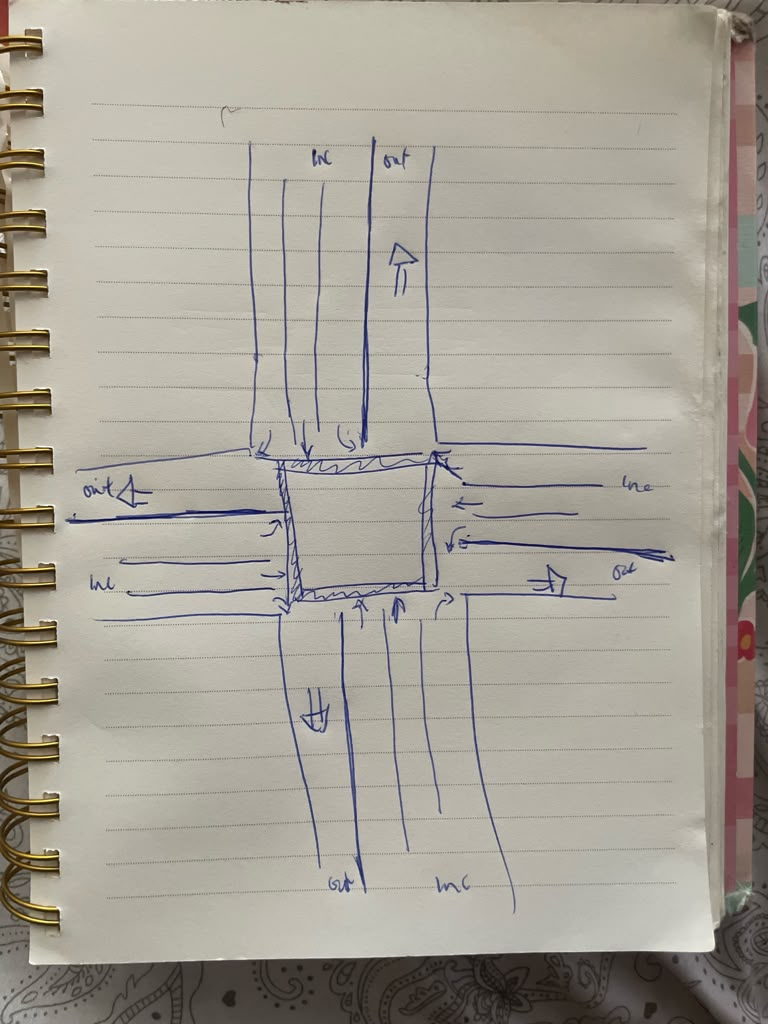

## **environment**

In [1]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces


class Traffic_Four_Way_Intersection_Environment(gym.Env):

    def __init__(
        self,
        episodes=5000,
        max_queue_length=20,
        green_light_capacity=5,
        outgoing_road_capacity=5,
        max_steps=100,
        use_argmax_policy=False,
        use_sensor_noise=False,
        sensor_noise_range=1,
        use_blocked_penalty=False,      # new feature: gap 1 fix
        blocked_penalty_weight=1.0,     # new feature: gap 1 fix
        use_fairness_penalty=False,     # new feature: gap 2 fix
        fairness_penalty_weight=0.1     # new feature: gap 2 fix
    ):

        # =====================================================
        # FOUR-WAY INTERSECTION
        # =====================================================

        r'''
                                      NORTH

                                      N_N
                                       ↑
                                       │

                         S_N      E_N      W_N
                           \       ↑       /
                            \      │      /
                             \     │     /
                              \    │    /
                               \   │   /
                                \  │  /
                                 \ │ /
                                  \│/

        WEST  W_W  ←────────── [ INTERSECTION ] ──────────→  E_E  EAST

                                  /│\
                                 / │ \
                                /  │  \
                               /   │   \
                              /    │    \
                             /     │     \
                            /      ↓      \
                         N_S      E_S      W_S

                                       │
                                       ↓
                                      S_S

                                      SOUTH
        '''


        # =====================================================
        # 1. THE 12 INCOMING TRAFFIC MOVEMENT QUEUES
        # =====================================================
        #
        # The first letter tells us WHERE THE CAR CAME FROM.
        #
        # The second letter tells us WHERE THE CAR WANTS TO GO.
        #
        #
        # Example:
        #
        # N_W
        #
        # N = entered from North
        # W = wants to leave toward West
        #
        #
        # A car entering from North has 3 possible destinations:
        #
        #       N_W = North -> West
        #       N_S = North -> South
        #       N_E = North -> East
        #
        #
        # There is no N_N because that would be a U-turn.
        #
        # =====================================================

        self.movements = [
            "N_W", "N_S", "N_E",
            "S_W", "S_N", "S_E",
            "E_N", "E_S", "E_W",
            "W_N", "W_S", "W_E"
        ]

        self.num_movements = len(self.movements)


        # =====================================================
        # 2. THE 4 OUTGOING ROAD QUEUES
        # =====================================================
        #
        # Once a car crosses the intersection, it enters one
        # of these outgoing roads.
        #
        #
        # Cars going NORTH:
        #
        # S_N ----\
        # E_N -----+----> N_N
        # W_N ----/
        #
        #
        # Cars going SOUTH:
        #
        # N_S ----\
        # E_S -----+----> S_S
        # W_S ----/
        #
        #
        # Cars going EAST:
        #
        # N_E ----\
        # S_E -----+----> E_E
        # W_E ----/
        #
        #
        # Cars going WEST:
        #
        # N_W ----\
        # S_W -----+----> W_W
        # E_W ----/
        #
        # =====================================================

        self.outgoing_movements = [
            "N_N",
            "S_S",
            "E_E",
            "W_W"
        ]

        self.num_outgoing = len(self.outgoing_movements)


        # =====================================================
        # COMPLETE STATE
        # =====================================================
        #
        # The state now has:
        #
        # 12 incoming movement queues
        # +
        # 4 outgoing road queues
        # =
        # 16 total queues
        #
        #
        # Index:
        #
        #  0  = N_W
        #  1  = N_S
        #  2  = N_E
        #
        #  3  = S_W
        #  4  = S_N
        #  5  = S_E
        #
        #  6  = E_N
        #  7  = E_S
        #  8  = E_W
        #
        #  9  = W_N
        # 10  = W_S
        # 11  = W_E
        #
        # 12  = N_N
        # 13  = S_S
        # 14  = E_E
        # 15  = W_W
        #
        #
        # Example state:
        #
        # [
        #     3, 8, 2,
        #     1, 5, 4,
        #     7, 2, 0,
        #     3, 6, 1,
        #
        #     2, 1, 4, 3
        # ]
        #
        # First 12 = waiting to cross intersection
        # Last 4  = already crossed and leaving the area
        #
        # =====================================================

        self.queue_names = self.movements + self.outgoing_movements

        self.num_total_queues = len(self.queue_names)


        # =====================================================
        # ACTION SPACE
        # =====================================================
        #
        # The RL agent still chooses ONE of the original
        # 12 traffic movements.
        #
        # Action 0  -> N_W
        # Action 1  -> N_S
        # Action 2  -> N_E
        # ...
        # Action 11 -> W_E
        #
        # The outgoing queues are NOT actions.
        #
        # We do not give a green light to N_N, S_S, E_E, W_W.
        # Those roads simply receive cars after they cross.
        #
        # =====================================================

        self.action_space = spaces.Discrete(
            self.num_movements
        )


        # =====================================================
        # OBSERVATION SPACE
        # =====================================================
        #
        # We now observe all 16 queues.
        #
        # Each queue can contain:
        #
        # 0, 1, 2, ..., max_queue_length
        #
        # If max_queue_length = 20:
        #
        # each queue has 21 possible values:
        #
        # 0 through 20
        #
        # =====================================================

        self.observation_space = spaces.MultiDiscrete(
            [max_queue_length + 1] * self.num_total_queues
        )


        # =====================================================
        # SAVE PARAMETERS AS INSTANCE VARIABLES
        # =====================================================

        self.max_queue = max_queue_length

        # Maximum number of simulation steps in one episode
        self.max_steps = max_steps

        # Maximum number of cars that can cross when one
        # movement receives a green light
        self.service_capacity = green_light_capacity

        # Maximum number of cars that can leave EACH outgoing
        # road during one time step
        self.outgoing_road_capacity = outgoing_road_capacity


        # =====================================================
        # MAP EACH MOVEMENT TO ITS OUTGOING ROAD
        # =====================================================
        #
        # Remember the state indexes:
        #
        # 12 = N_N
        # 13 = S_S
        # 14 = E_E
        # 15 = W_W
        #
        #
        # Example:
        #
        # N_W
        #   |
        #   | car crosses
        #   v
        # W_W
        #
        #
        # N_W ----\
        # S_W -----+----> W_W
        # E_W ----/
        #
        # =====================================================

        self.movement_to_outgoing = {

            # Cars leaving toward WEST
            "N_W": 15,
            "S_W": 15,
            "E_W": 15,

            # Cars leaving toward SOUTH
            "N_S": 13,
            "E_S": 13,
            "W_S": 13,

            # Cars leaving toward EAST
            "N_E": 14,
            "S_E": 14,
            "W_E": 14,

            # Cars leaving toward NORTH
            "S_N": 12,
            "E_N": 12,
            "W_N": 12
        }


        # =====================================================
        # WHO CONTROLS THE TRAFFIC SIGNAL?
        # =====================================================
        #
        # True:
        #
        #     Baseline automatically chooses the largest
        #     incoming movement queue.
        #
        #
        # False:
        #
        #     Q-learning / SARSA / DQN chooses the action.
        #
        # =====================================================

        self.use_argmax_policy = use_argmax_policy


        # =====================================================
        # SENSOR NOISE SETTINGS
        # =====================================================
        #
        # Everything above this point assumes the agent gets
        # PERFECT knowledge of all 16 queues. In real life, a
        # traffic signal only knows what its sensors report --
        # inductive loop detectors, cameras, radar -- and those
        # sensors are never perfectly accurate.
        #
        #
        # use_sensor_noise = False (default):
        #
        #     The agent sees the TRUE values for all 16 queues.
        #     Nothing changes from the behavior above.
        #
        #
        # use_sensor_noise = True:
        #
        #     The environment still tracks the TRUE values
        #     internally (reward always uses these, since
        #     reward must reflect what actually happened).
        #
        #     But whatever gets RETURNED to the agent from
        #     reset() and step() is a noisy estimate instead,
        #     across all 16 queues -- 12 incoming AND the 4
        #     outgoing roads.
        #
        #
        # sensor_noise_range:
        #
        #     How far off a single sensor reading can be.
        #
        #     Example: sensor_noise_range = 1
        #
        #     True value:      8
        #     Possible reading: 7, 8, or 9
        #
        # =====================================================

        self.use_sensor_noise = use_sensor_noise
        self.sensor_noise_range = sensor_noise_range


        # new feature: gap 1 fix -- blocked cars weren't penalized
        # in reward before; these two lines let that be toggled on
        self.use_blocked_penalty = use_blocked_penalty
        self.blocked_penalty_weight = blocked_penalty_weight

        # new feature: gap 2 fix -- nothing tracked how long a
        # movement went unserved before; steps_since_served is a
        # counter per movement, incremented in step() below
        self.use_fairness_penalty = use_fairness_penalty
        self.fairness_penalty_weight = fairness_penalty_weight
        self.steps_since_served = np.zeros(self.num_movements, dtype=int)


        # State will be initialized by reset()
        self.state = None

        # Number of steps completed in current episode
        self.current_step = 0


    # =========================================================
    # SENSOR READING
    # =========================================================

    def sensor_reading(self, true_state):

        # -----------------------------------------------------
        # Add random noise to every one of the 16 true values.
        #
        # Example with sensor_noise_range = 1:
        #
        # noise for each queue is randomly -1, 0, or +1
        #
        #
        # True state:
        #
        # [8, 3, ...]
        #
        # Noise:
        #
        # [+1, -1, ...]
        #
        # Observed:
        #
        # [9, 2, ...]
        # -----------------------------------------------------

        noise = self.np_random.integers(
            low=-self.sensor_noise_range,
            high=self.sensor_noise_range + 1,
            size=self.num_total_queues
        )

        observed = true_state + noise


        # -----------------------------------------------------
        # A sensor cannot report a negative number of cars,
        # and cannot report more cars than the queue could
        # physically hold.
        # -----------------------------------------------------

        observed = np.clip(
            observed,
            0,
            self.max_queue
        )

        return observed


    # =========================================================
    # GET OBSERVATION
    # =========================================================
    #
    # This decides what the AGENT actually gets to see.
    #
    # If sensor noise is off: the true state, exactly as before.
    #
    # If sensor noise is on: a noisy reading instead.
    #
    # Reward is NEVER calculated from this -- reward always
    # uses self.state (the true values) directly inside step().
    #
    # =========================================================

    def _get_observation(self):

        if self.use_sensor_noise:

            return self.sensor_reading(self.state)

        else:

            return self.state.copy()


    # =========================================================
    # RESET
    # =========================================================

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0

        # new feature: gap 2 fix -- reset the unserved-streak
        # counters at the start of every new episode
        self.steps_since_served = np.zeros(self.num_movements, dtype=int)

        # -----------------------------------------------------
        # INITIAL INCOMING TRAFFIC
        # -----------------------------------------------------
        #
        # Each of the 12 incoming movement queues starts
        # randomly with between 0 and 5 cars.
        #
        # high=6 means:
        #
        # possible values:
        #
        # 0, 1, 2, 3, 4, 5
        #
        # -----------------------------------------------------

        incoming_state = self.np_random.integers(
            low=0,
            high=6,
            size=self.num_movements
        )


        # -----------------------------------------------------
        # INITIAL OUTGOING TRAFFIC
        # -----------------------------------------------------
        #
        # At the beginning of a new episode, no cars have
        # crossed the intersection yet.
        #
        # N_N = 0
        # S_S = 0
        # E_E = 0
        # W_W = 0
        #
        # -----------------------------------------------------

        outgoing_state = np.zeros(
            self.num_outgoing,
            dtype=int
        )


        # -----------------------------------------------------
        # COMBINE EVERYTHING INTO ONE STATE
        # -----------------------------------------------------
        #
        # Incoming queues:
        #
        # indexes 0 through 11
        #
        # Outgoing queues:
        #
        # indexes 12 through 15
        #
        # -----------------------------------------------------

        self.state = np.concatenate(
            (
                incoming_state,
                outgoing_state
            )
        )


        return self._get_observation(), {}


    # =========================================================
    # STEP
    # =========================================================

    def step(self, action):

        self.current_step += 1


        # Make a copy so we can calculate the next state
        # without immediately changing the current state.

        next_state = self.state.copy()


        # =====================================================
        # STEP 1:
        # CARS ALREADY ON OUTGOING ROADS LEAVE THE SYSTEM
        # =====================================================
        #
        # The outgoing roads cannot collect cars forever.
        #
        # Cars continue driving away from the intersection.
        #
        #
        # Example:
        #
        # W_W currently contains 8 cars
        #
        # outgoing_road_capacity = 5
        #
        # 5 cars leave the modeled area
        #
        # W_W:
        #
        # 8 -> 3
        #
        #
        # This happens independently for:
        #
        # N_N
        # S_S
        # E_E
        # W_W
        #
        # =====================================================

        outgoing_departures = np.minimum(
            next_state[12:16],
            self.outgoing_road_capacity
        )

        next_state[12:16] -= outgoing_departures


        # =====================================================
        # STEP 2:
        # DECIDE WHICH MOVEMENT GETS THE GREEN LIGHT
        # =====================================================

        if self.use_argmax_policy:

            # -------------------------------------------------
            # BASELINE MODE
            #
            # Look ONLY at the first 12 queues.
            #
            # Outgoing roads are not signal choices.
            #
            # Choose whichever incoming movement currently
            # has the largest queue.
            # -------------------------------------------------

            selected_index = int(
                np.argmax(next_state[:self.num_movements])
            )

        else:

            # -------------------------------------------------
            # LEARNING MODE
            #
            # The action chosen by Q-learning, SARSA, or DQN
            # determines which movement gets green.
            # -------------------------------------------------

            if not self.action_space.contains(action):
                raise ValueError(
                    f"Invalid action {action}. "
                    f"Action must be between 0 and "
                    f"{self.num_movements - 1}."
                )

            selected_index = int(action)


        selected_movement = self.movements[selected_index]


        # new feature: gap 2 fix -- every movement's unserved
        # streak goes up by 1, then whichever movement just got
        # served resets back to 0 (order matters here)
        self.steps_since_served += 1
        self.steps_since_served[selected_index] = 0


        # =====================================================
        # STEP 3:
        # FIND THE CORRECT OUTGOING ROAD
        # =====================================================
        #
        # Example:
        #
        # selected movement = N_W
        #
        # N_W means:
        #
        # came from North
        # going toward West
        #
        # Therefore:
        #
        # N_W
        #   |
        #   v
        # W_W
        #
        # =====================================================

        outgoing_index = self.movement_to_outgoing[
            selected_movement
        ]

        outgoing_movement = self.queue_names[
            outgoing_index
        ]


        # =====================================================
        # STEP 4:
        # GIVE THE SELECTED MOVEMENT A GREEN LIGHT
        # =====================================================

        cars_waiting = next_state[selected_index]


        # -----------------------------------------------------
        # First determine how many cars WOULD be able to pass
        # based only on the green-light capacity.
        #
        # Example:
        #
        # N_W = 8
        #
        # green_light_capacity = 5
        #
        # requested_to_pass = 5
        #
        # -----------------------------------------------------

        requested_to_pass = min(
            cars_waiting,
            self.service_capacity
        )


        # -----------------------------------------------------
        # Check how much room exists on the outgoing road.
        #
        # Example:
        #
        # W_W currently = 18
        # max_queue = 20
        #
        # available space = 2
        #
        # Even if 5 cars want to cross,
        # only 2 can enter W_W.
        #
        # -----------------------------------------------------

        outgoing_space_available = (
            self.max_queue
            - next_state[outgoing_index]
        )


        # -----------------------------------------------------
        # Actual number of cars that can pass
        #
        # Must satisfy ALL THREE:
        #
        # 1. Cars must actually be waiting.
        #
        # 2. Green light has a maximum service capacity.
        #
        # 3. Outgoing road must have enough room.
        #
        # -----------------------------------------------------

        cars_passed = min(
            requested_to_pass,
            outgoing_space_available
        )


        # -----------------------------------------------------
        # Remove cars from incoming movement
        # -----------------------------------------------------

        next_state[selected_index] -= cars_passed


        # -----------------------------------------------------
        # Add those SAME cars to outgoing road
        #
        # They do not magically disappear.
        #
        # Example:
        #
        # Before:
        #
        # N_W = 8
        # W_W = 2
        #
        #
        # 5 cars cross
        #
        #
        # After:
        #
        # N_W = 3
        # W_W = 7
        #
        # -----------------------------------------------------

        next_state[outgoing_index] += cars_passed


        # -----------------------------------------------------
        # Cars that wanted to cross but could not because the
        # outgoing road was full stay in their incoming queue.
        #
        # They are NOT deleted.
        # -----------------------------------------------------

        blocked_by_outgoing = (
            requested_to_pass
            - cars_passed
        )


        # =====================================================
        # STEP 5:
        # NEW CARS ARRIVE
        # =====================================================
        #
        # Each incoming movement receives:
        #
        # 0, 1, or 2 new cars
        #
        #
        # IMPORTANT:
        #
        # A car keeps its intended direction.
        #
        # If an N_W car arrives, it must join N_W.
        #
        # We DO NOT move it to N_S or N_E just because
        # N_W happens to be full.
        #
        #
        # This fixes the old fallback behavior.
        #
        # =====================================================

        arrivals = self.np_random.integers(
            low=0,
            high=3,
            size=self.num_movements
        )


        blocked_arrivals = 0


        for movement_index in range(
            self.num_movements
        ):

            number_of_arriving_cars = arrivals[
                movement_index
            ]


            # Add each arriving car to its intended
            # movement queue.

            for _ in range(
                number_of_arriving_cars
            ):

                if (
                    next_state[movement_index]
                    < self.max_queue
                ):

                    next_state[movement_index] += 1

                else:

                    # The intended queue is full.
                    #
                    # The car is counted as blocked instead
                    # of magically changing destinations.

                    blocked_arrivals += 1


        # =====================================================
        # STEP 6:
        # CALCULATE REWARD
        # =====================================================
        #
        # We count congestion in the entire modeled system:
        #
        # incoming queues
        # +
        # outgoing queues
        #
        #
        # Fewer cars waiting in the system
        # =
        # better reward.
        #
        #
        # Example:
        #
        # total_system_queue = 40
        #
        # reward = -40
        #
        #
        # Smaller congestion:
        #
        # -20 is better than -40
        #
        #
        # IMPORTANT: reward always uses next_state, which
        # holds the TRUE values -- never the noisy sensor
        # reading. Noise only affects what the agent SEES,
        # never what actually happened.
        #
        # =====================================================

        incoming_waiting = int(
            np.sum(
                next_state[:self.num_movements]
            )
        )

        outgoing_waiting = int(
            np.sum(
                next_state[self.num_movements:]
            )
        )

        total_system_queue = (
            incoming_waiting
            + outgoing_waiting
        )

        reward = -total_system_queue

        # new feature: gap 1 fix -- only applies if toggled on,
        # otherwise reward is identical to the original line above
        if self.use_blocked_penalty:
            reward -= self.blocked_penalty_weight * (
                blocked_by_outgoing + blocked_arrivals
            )

        # new feature: gap 2 fix -- only applies if toggled on,
        # otherwise reward is identical to the original line above
        if self.use_fairness_penalty:
            reward -= self.fairness_penalty_weight * np.sum(
                self.steps_since_served
            )


        # =====================================================
        # STEP 7:
        # UPDATE THE ENVIRONMENT
        # =====================================================

        self.state = next_state


        # There is no natural terminal state.
        #
        # The simulation ends because we reach max_steps.

        terminated = False


        truncated = (
            self.current_step >= self.max_steps
        )


        # =====================================================
        # INFORMATION FOR TESTING AND ANALYSIS
        # =====================================================

        info = {

            # Which signal movement received green
            "selected_movement":
                selected_movement,

            # Where the cars went
            "outgoing_movement":
                outgoing_movement,

            # Number of cars waiting before green
            "selected_queue_before_green":
                int(cars_waiting),

            # Number that actually crossed
            "cars_passed":
                int(cars_passed),

            # Cars unable to cross because outgoing road
            # lacked enough room
            "blocked_by_outgoing":
                int(blocked_by_outgoing),

            # New arrivals rejected because their intended
            # incoming movement queue was full
            "blocked_arrivals":
                int(blocked_arrivals),

            # Number waiting before the intersection
            "incoming_waiting":
                incoming_waiting,

            # Number currently on outgoing roads
            "outgoing_waiting":
                outgoing_waiting,

            # Total cars represented by all queues
            "total_system_queue":
                total_system_queue,

            # Cars that completely left the modeled system
            # during this step
            "cars_left_system":
                int(
                    np.sum(
                        outgoing_departures
                    )
                ),

            # new feature: gap 2 fix -- lets you inspect how long
            # each movement has gone unserved
            "steps_since_served":
                self.steps_since_served.copy()
        }


        return (
            self._get_observation(),
            reward,
            terminated,
            truncated,
            info
        )


# =============================================================
# QUICK TEST
# =============================================================

if __name__ == "__main__":

    print(
        "=============================================="
    )

    print(
        "TESTING BASELINE MODE"
    )

    print(
        "Largest incoming queue gets green automatically"
    )

    print(
        "=============================================="
    )


    baseline_env = (
        Traffic_Four_Way_Intersection_Environment(
            use_argmax_policy=True
        )
    )


    state, info = baseline_env.reset()


    print(
        "\nInitial state:"
    )

    print(
        state
    )


    print(
        "\nQueue names:"
    )

    for index, name in enumerate(
        baseline_env.queue_names
    ):

        print(
            f"{index:>2}: {name}"
        )


    print(
        "\n----------------------------------------------"
    )


    for step_number in range(5):

        # Ignored because baseline chooses the largest queue
        random_action = (
            baseline_env.action_space.sample()
        )


        (
            state,
            reward,
            terminated,
            truncated,
            info
        ) = baseline_env.step(
            random_action
        )


        print(
            f"\nSTEP {step_number + 1}"
        )


        print(
            f"Green movement: "
            f"{info['selected_movement']}"
        )


        print(
            f"Cars moved into: "
            f"{info['outgoing_movement']}"
        )


        print(
            f"Cars passed: "
            f"{info['cars_passed']}"
        )


        print(
            f"Cars left entire system: "
            f"{info['cars_left_system']}"
        )


        print(
            f"Incoming waiting: "
            f"{info['incoming_waiting']}"
        )


        print(
            f"Outgoing waiting: "
            f"{info['outgoing_waiting']}"
        )


        print(
            f"Reward: "
            f"{reward}"
        )


        print(
            f"State: "
            f"{state}"
        )


    print(
        "\n=============================================="
    )

    print(
        "TESTING LEARNING MODE"
    )

    print(
        "Agent action determines which movement gets green"
    )

    print(
        "=============================================="
    )


    learning_env = (
        Traffic_Four_Way_Intersection_Environment(
            use_argmax_policy=False
        )
    )


    state, info = learning_env.reset()


    for step_number in range(5):

        random_action = (
            learning_env.action_space.sample()
        )


        (
            state,
            reward,
            terminated,
            truncated,
            info
        ) = learning_env.step(
            random_action
        )


        print(
            f"\nSTEP {step_number + 1}"
        )


        print(
            f"Agent selected: "
            f"{info['selected_movement']}"
        )


        print(
            f"Cars entered: "
            f"{info['outgoing_movement']}"
        )


        print(
            f"Cars passed: "
            f"{info['cars_passed']}"
        )


        print(
            f"Reward: "
            f"{reward}"
        )


        print(
            f"State: "
            f"{state}"
        )


    print(
        "\n=============================================="
    )

    print(
        "TESTING SENSOR NOISE MODE"
    )

    print(
        "Agent sees noisy readings; reward uses true state"
    )

    print(
        "=============================================="
    )


    noisy_env = (
        Traffic_Four_Way_Intersection_Environment(
            use_argmax_policy=False,
            use_sensor_noise=True,
            sensor_noise_range=1
        )
    )


    observed_state, info = noisy_env.reset()

    print(
        "\nObserved (noisy) initial state:"
    )

    print(
        observed_state
    )

    print(
        "True internal state:"
    )

    print(
        noisy_env.state
    )


    for step_number in range(5):

        random_action = (
            noisy_env.action_space.sample()
        )

        (
            observed_state,
            reward,
            terminated,
            truncated,
            info
        ) = noisy_env.step(
            random_action
        )

        print(
            f"\nSTEP {step_number + 1}"
        )

        print(
            f"Observed state: {observed_state}"
        )

        print(
            f"True state:     {noisy_env.state}"
        )

        print(
            f"Reward (uses TRUE state): {reward}"
        )





TESTING BASELINE MODE
Largest incoming queue gets green automatically

Initial state:
[4 1 2 2 1 2 2 3 5 0 5 3 0 0 0 0]

Queue names:
 0: N_W
 1: N_S
 2: N_E
 3: S_W
 4: S_N
 5: S_E
 6: E_N
 7: E_S
 8: E_W
 9: W_N
10: W_S
11: W_E
12: N_N
13: S_S
14: E_E
15: W_W

----------------------------------------------

STEP 1
Green movement: E_W
Cars moved into: W_W
Cars passed: 5
Cars left entire system: 0
Incoming waiting: 40
Outgoing waiting: 5
Reward: -45
State: [4 1 3 4 3 4 4 5 1 0 7 4 0 0 0 5]

STEP 2
Green movement: W_S
Cars moved into: S_S
Cars passed: 5
Cars left entire system: 5
Incoming waiting: 44
Outgoing waiting: 5
Reward: -49
State: [6 2 5 6 3 4 4 5 1 2 2 4 0 5 0 0]

STEP 3
Green movement: N_W
Cars moved into: W_W
Cars passed: 5
Cars left entire system: 5
Incoming waiting: 54
Outgoing waiting: 5
Reward: -59
State: [2 4 7 8 5 4 6 7 2 3 2 4 0 0 0 5]

STEP 4
Green movement: S_W
Cars moved into: W_W
Cars passed: 5
Cars left entire system: 5
Incoming waiting: 59
Outgoing waiting: 5
Rew

# **State discretzier bucketing function**

In [2]:
import numpy as np


def discretize_state(state, max_queue_length=20, num_buckets=2):
    """
    Converts the true 16-value queue state (12 incoming + 4 outgoing,
    each 0-20) into a smaller bucketed version, e.g. "low"/"high"
    instead of an exact count. This is what lets a Q-table stay a
    manageable size -- full precision would mean 21^16 possible
    states, which is far too many to ever learn from directly.

    Only used by tabular methods (Q-learning, SARSA). DQN works on
    the full-precision state directly, since it doesn't need a table.

    Returns a tuple (hashable, so it can be used as a Q-table key).
    """

    # Each queue holds 0 to max_queue_length (max_queue_length + 1
    # possible values). Dividing that range evenly across num_buckets
    # tells us how many values fall into each bucket.
    # e.g. max_queue_length=20, num_buckets=2 -> bucket_width ~10.5
    #      bucket 0 ("low")  = 0-10
    #      bucket 1 ("high") = 11-20
    bucket_width = (max_queue_length + 1) / num_buckets

    # Sort every one of the 16 queue values into its bucket.
    # min(..., num_buckets - 1) is just a safety net so a value at
    # the very top of the range (e.g. exactly 20) can't round into
    # a bucket number that doesn't exist.
    bucketed = tuple(
        min(int(value // bucket_width), num_buckets - 1)
        for value in state
    )

    return bucketed


if __name__ == "__main__":

    # Example state matching the environment's order: 12 incoming
    # queues, then the 4 outgoing queues (N_N, S_S, E_E, W_W).
    example_state = np.array([
        0, 6, 7, 13, 14, 20, 3, 9, 15, 1, 19, 10,   # incoming
        2, 8, 16, 5                                  # outgoing
    ])

    bucketed_state = discretize_state(example_state, max_queue_length=20, num_buckets=2)

    print("Original state:", example_state)
    print("Bucketed state:", bucketed_state)
    print("Still 16 values?", len(bucketed_state) == 16)

    # Why we picked 2 buckets: comparing how big the state space
    # gets at different bucket counts.
    print(f"\n21^16 = {21**16:,}   (full precision, unusable for a table)")
    print(f"2^16  = {2**16:,}   (2 buckets -- what we're using)")
    print(f"3^16  = {3**16:,}   (3 buckets -- for comparison)")

Original state: [ 0  6  7 13 14 20  3  9 15  1 19 10  2  8 16  5]
Bucketed state: (0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0)
Still 16 values? True

21^16 = 1,430,568,690,241,985,328,321   (full precision, unusable for a table)
2^16  = 65,536   (2 buckets -- what we're using)
3^16  = 43,046,721   (3 buckets -- for comparison)


## **Q learning**

In [3]:
import numpy as np
from collections import defaultdict


def train_q_learning(
    num_episodes=2000,
    max_queue_length=20,
    num_buckets=2,          # 2 buckets chosen for the 16-dim state -- keeps the table to 2^16 = 65,536 possible states, small enough to actually train on
    green_light_capacity=5,
    outgoing_road_capacity=5,
    max_steps=100,
    alpha=0.1,          # learning rate -- how much each new experience shifts our estimate of Q(s,a)
    gamma=0.9,           # discount factor -- how much the agent weighs future reward vs immediate reward
    epsilon_start=1.0,   # start fully random, since the agent knows nothing yet
    epsilon_end=0.05,    # never fully stop exploring -- always keep a little randomness
    epsilon_decay=0.995,  # multiply epsilon by this after every episode, so exploration fades gradually
    use_blocked_penalty=False,      # gap 1 fix -- pass-through so this can be toggled from here
    blocked_penalty_weight=1.0,     # gap 1 fix
    use_fairness_penalty=False,     # gap 2 fix -- pass-through so this can be toggled from here
    fairness_penalty_weight=0.1,
    use_sensor_noise=False,
    sensor_noise_range=1
):
    """
    Trains a tabular Q-learning agent on the 16-queue traffic
    environment (12 incoming + 4 outgoing). Returns the learned
    Q-table and a list of total reward per episode, so the
    learning curve can be plotted afterward.

    Assumes Traffic_Four_Way_Intersection_Environment and
    discretize_state are already defined (from earlier cells).
    """

    # LEARNING MODE: use_argmax_policy=False means the environment
    # obeys whatever action we pass into step(), instead of always
    # picking the biggest queue itself.
    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        green_light_capacity=green_light_capacity,
        outgoing_road_capacity=outgoing_road_capacity,
        max_steps=max_steps,
        use_argmax_policy=False,
        use_blocked_penalty=use_blocked_penalty,
        blocked_penalty_weight=blocked_penalty_weight,
        use_fairness_penalty=use_fairness_penalty,
        fairness_penalty_weight=fairness_penalty_weight,
        use_sensor_noise=use_sensor_noise,
        sensor_noise_range=sensor_noise_range
    )

    num_actions = env.action_space.n

    # Q-table: a dictionary. Key = bucketed 16-value state tuple.
    # Value = array of 12 numbers, one estimated "goodness" score
    # per action. defaultdict automatically creates a fresh
    # all-zero row the first time a new state is seen, so we never
    # need to pre-build the whole table in advance.
    Q = defaultdict(lambda: np.zeros(num_actions))

    epsilon = epsilon_start
    episode_rewards = []   # total reward per episode, for plotting later
    episode_queue_totals = []   # total_system_queue per episode -- fair comparison metric, unaffected by reward shaping

    for episode in range(num_episodes):

        state, info = env.reset()
        state_key = discretize_state(state, max_queue_length, num_buckets)

        total_reward = 0
        total_queue = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            # EPSILON-GREEDY ACTION SELECTION
            # With probability epsilon: pick a random action (explore).
            # Otherwise: pick whichever action currently looks best
            # in the Q-table for this state (exploit).
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state_key]))

            next_state, reward, terminated, truncated, info = env.step(action)
            next_state_key = discretize_state(next_state, max_queue_length, num_buckets)

            # Q-LEARNING UPDATE RULE:
            # Q(s,a) <- Q(s,a) + alpha * [reward + gamma * max_a' Q(s',a') - Q(s,a)]
            #
            # In plain terms: nudge our estimate of how good this
            # (state, action) pair was, based on the reward we
            # actually got plus the best possible value from the
            # next state. This is the "off-policy" part -- Q-learning
            # assumes we'll act greedily going forward, even though
            # we might explore again on the next step.
            # -------------------------------------------------
            # TERMINAL-STATE CHECK
            #
            # Normal Q-learning target:
            #
            #     reward + gamma * max Q(next_state)
            #
            # But when the episode is over there is no future
            # state to learn from, so the future value is ZERO.
            #
            #       episode continues       episode ends
            #              |                     |
            #              v                     v
            #   r + gamma * max Q(s')           r
            # -------------------------------------------------
            done = terminated or truncated
            best_next_value = 0.0 if done else np.max(Q[next_state_key])
            td_target = reward + gamma * best_next_value
            td_error = td_target - Q[state_key][action]
            Q[state_key][action] += alpha * td_error

            state_key = next_state_key
            total_reward += reward
            total_queue += info["total_system_queue"]

        # decay epsilon after each episode so exploration fades over time
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)
        episode_queue_totals.append(total_queue)

        # print progress every ~10% of training so we can watch it learn
        if (episode + 1) % max(1, num_episodes // 10) == 0:
            recent_avg = np.mean(episode_rewards[-max(1, num_episodes // 10):])
            print(f"Episode {episode+1:>5}/{num_episodes} | "
                  f"epsilon={epsilon:.3f} | "
                  f"avg reward (last batch)={recent_avg:.1f} | "
                  f"Q-table size={len(Q)} states")

    return Q, episode_rewards, episode_queue_totals


if __name__ == "__main__":

    # Small smoke test first -- confirms nothing crashes and reward
    # trends upward (less negative) before committing to a full,
    # much longer training run.
    print("=== Smoke test: 200 episodes ===\n")

    Q_q_test, rewards_q_test, queue_totals_q_test = train_q_learning(num_episodes=200)

    print("\nDistinct states visited:", len(Q_q_test))
    print("Avg reward, first 20 episodes:", round(np.mean(rewards_q_test[:20]), 1))
    print("Avg reward, last 20 episodes: ", round(np.mean(rewards_q_test[-20:]), 1))
    print("(last 20 less negative than first 20 = the agent is learning)")

=== Smoke test: 200 episodes ===

Episode    20/200 | epsilon=0.905 | avg reward (last batch)=-19843.0 | Q-table size=236 states
Episode    40/200 | epsilon=0.818 | avg reward (last batch)=-19842.4 | Q-table size=415 states
Episode    60/200 | epsilon=0.740 | avg reward (last batch)=-19705.0 | Q-table size=561 states
Episode    80/200 | epsilon=0.670 | avg reward (last batch)=-19680.8 | Q-table size=699 states
Episode   100/200 | epsilon=0.606 | avg reward (last batch)=-19671.1 | Q-table size=834 states
Episode   120/200 | epsilon=0.548 | avg reward (last batch)=-19388.9 | Q-table size=938 states
Episode   140/200 | epsilon=0.496 | avg reward (last batch)=-19536.5 | Q-table size=1022 states
Episode   160/200 | epsilon=0.448 | avg reward (last batch)=-19593.5 | Q-table size=1105 states
Episode   180/200 | epsilon=0.406 | avg reward (last batch)=-19426.4 | Q-table size=1187 states
Episode   200/200 | epsilon=0.367 | avg reward (last batch)=-19396.7 | Q-table size=1270 states

Distinct st

## **plot learning curves**

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def plot_learning_curve(episode_rewards, window=100, title="Q-Learning Reward Over Time"):
    """
    Plots total reward per episode across training, plus a smoothed
    moving-average line so the overall trend is easy to see through
    the natural episode-to-episode noise.

    episode_rewards: the list returned by train_q_learning()
    window: how many episodes to average over for the smoothed line
            (e.g. 100 = each point on the smooth line is the average
            of the last 100 episodes, which is why it starts partway in)
    """

    episodes = np.arange(1, len(episode_rewards) + 1)

    # Raw per-episode reward (noisy, since each episode has random arrivals)
    plt.figure(figsize=(10, 5))
    plt.plot(episodes, episode_rewards, alpha=0.25, label="Raw reward per episode")

    # Smoothed moving average -- this is the line that actually shows the trend
    if len(episode_rewards) >= window:
        moving_avg = np.convolve(
            episode_rewards,
            np.ones(window) / window,
            mode="valid"
        )
        # moving_avg[i] corresponds to episodes[i + window - 1]
        plt.plot(
            episodes[window - 1:],
            moving_avg,
            linewidth=2,
            label=f"{window}-episode moving average"
        )

    plt.xlabel("Episode")
    plt.ylabel("Total reward (higher / less negative = better)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



### **q learning curves on 5000 episodes**

Episode   500/5000 | epsilon=0.082 | avg reward (last batch)=-19467.2 | Q-table size=1997 states
Episode  1000/5000 | epsilon=0.050 | avg reward (last batch)=-19208.2 | Q-table size=2790 states
Episode  1500/5000 | epsilon=0.050 | avg reward (last batch)=-19130.0 | Q-table size=3313 states
Episode  2000/5000 | epsilon=0.050 | avg reward (last batch)=-19067.5 | Q-table size=3614 states
Episode  2500/5000 | epsilon=0.050 | avg reward (last batch)=-19059.2 | Q-table size=3839 states
Episode  3000/5000 | epsilon=0.050 | avg reward (last batch)=-19004.5 | Q-table size=3947 states
Episode  3500/5000 | epsilon=0.050 | avg reward (last batch)=-19013.1 | Q-table size=4024 states
Episode  4000/5000 | epsilon=0.050 | avg reward (last batch)=-18964.2 | Q-table size=4069 states
Episode  4500/5000 | epsilon=0.050 | avg reward (last batch)=-18964.3 | Q-table size=4085 states
Episode  5000/5000 | epsilon=0.050 | avg reward (last batch)=-18923.3 | Q-table size=4093 states


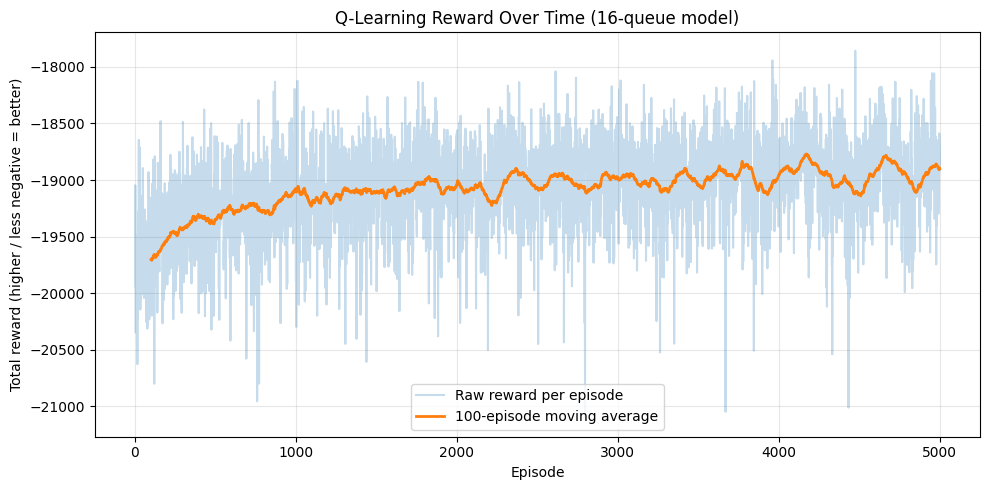

In [5]:
# Train the final 5,000-episode epsilon-greedy Q-learning agent.
# Use unique variable names so later smoke tests cannot overwrite these results.

Q_qlearning, rewards_qlearning, queue_totals_qlearning = train_q_learning(
    num_episodes=5000
)

plot_learning_curve(
    rewards_qlearning,
    window=100,
    title="Q-Learning Reward Over Time (16-queue model)"
)


# **Sarsa**

In [6]:
import numpy as np
from collections import defaultdict


def train_sarsa(
    num_episodes=2000,
    max_queue_length=20,
    num_buckets=2,          # keeping 2 buckets, same as Q-learning, for a fair comparison
    green_light_capacity=5,
    outgoing_road_capacity=5,
    max_steps=100,
    alpha=0.1,          # learning rate
    gamma=0.9,           # discount factor
    epsilon_start=1.0,   # start fully random
    epsilon_end=0.05,    # never fully stop exploring
    epsilon_decay=0.995,  # exploration fades gradually each episode
    use_blocked_penalty=False,      # gap 1 fix -- pass-through
    blocked_penalty_weight=1.0,     # gap 1 fix
    use_fairness_penalty=False,     # gap 2 fix -- pass-through
    fairness_penalty_weight=0.1,
    use_sensor_noise=False,
    sensor_noise_range=1
):
    """
    Trains a tabular SARSA agent on the 16-queue traffic
    environment. Structurally almost identical to
    train_q_learning() -- same environment, same discretizer,
    same epsilon-greedy setup. The only real difference is the
    update rule itself (see below).

    Assumes Traffic_Four_Way_Intersection_Environment and
    discretize_state are already defined (from earlier cells).
    """

    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        green_light_capacity=green_light_capacity,
        outgoing_road_capacity=outgoing_road_capacity,
        max_steps=max_steps,
        use_argmax_policy=False,
        use_blocked_penalty=use_blocked_penalty,
        blocked_penalty_weight=blocked_penalty_weight,
        use_fairness_penalty=use_fairness_penalty,
        fairness_penalty_weight=fairness_penalty_weight,
        use_sensor_noise=use_sensor_noise,
        sensor_noise_range=sensor_noise_range
    )

    num_actions = env.action_space.n

    Q = defaultdict(lambda: np.zeros(num_actions))

    epsilon = epsilon_start
    episode_rewards = []
    episode_queue_totals = []   # total_system_queue per episode -- fair comparison metric, unaffected by reward shaping

    def choose_action(state_key, epsilon):
        """Epsilon-greedy action selection -- identical to Q-learning's."""
        if np.random.random() < epsilon:
            return env.action_space.sample()
        else:
            return int(np.argmax(Q[state_key]))

    for episode in range(num_episodes):

        state, info = env.reset()
        state_key = discretize_state(state, max_queue_length, num_buckets)

        # KEY SARSA DIFFERENCE: pick the first action before the loop
        # even starts, and carry it forward into the next iteration.
        # Q-learning never needs to commit to a next action in
        # advance -- it just looks at the best possible one.
        action = choose_action(state_key, epsilon)

        total_reward = 0
        total_queue = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            next_state, reward, terminated, truncated, info = env.step(action)
            next_state_key = discretize_state(next_state, max_queue_length, num_buckets)

            # -------------------------------------------------
            # DID THE EPISODE END?
            #
            # If not, SARSA chooses the actual next action a'
            # from its current epsilon-greedy policy.
            #
            # If the episode ended, there is NO next action and
            # therefore NO future Q-value to add.
            #
            #        not done                    done
            #           |                          |
            #           v                          v
            # choose next_action              no next action
            #           |                          |
            #           v                          v
            # r + gamma*Q(s',a')                  r
            # -------------------------------------------------
            done = terminated or truncated

            if not done:
                # Pick the NEXT action now, using the current policy.
                # This is what makes SARSA "on-policy".
                next_action = choose_action(next_state_key, epsilon)
            else:
                next_action = None

            # SARSA UPDATE RULE:
            # Q(s,a) <- Q(s,a) + alpha * [reward + gamma * Q(s',a') - Q(s,a)]
            #
            # Compare to Q-learning's:
            # Q(s,a) <- Q(s,a) + alpha * [reward + gamma * max_a' Q(s',a') - Q(s,a)]
            #
            # The only difference: SARSA uses Q(s', a') -- the value
            # of the specific next action it already committed to --
            # instead of max_a' Q(s',a'), the best possible next
            # action regardless of whether it'll actually be taken.
            if done:
                td_target = reward
            else:
                td_target = reward + gamma * Q[next_state_key][next_action]

            td_error = td_target - Q[state_key][action]
            Q[state_key][action] += alpha * td_error

            # Carry the state forward.
            # Only carry next_action forward when another step exists.
            state_key = next_state_key
            if not done:
                action = next_action

            total_reward += reward
            total_queue += info["total_system_queue"]

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)
        episode_queue_totals.append(total_queue)

        if (episode + 1) % max(1, num_episodes // 10) == 0:
            recent_avg = np.mean(episode_rewards[-max(1, num_episodes // 10):])
            print(f"Episode {episode+1:>5}/{num_episodes} | "
                  f"epsilon={epsilon:.3f} | "
                  f"avg reward (last batch)={recent_avg:.1f} | "
                  f"Q-table size={len(Q)} states")

    return Q, episode_rewards, episode_queue_totals


if __name__ == "__main__":

    print("=== Smoke test: 200 episodes ===\n")

    Q_sarsa_test, rewards_sarsa_test, queue_totals_sarsa_test = train_sarsa(num_episodes=200)

    print("\nDistinct states visited:", len(Q_sarsa_test))
    print("Avg reward, first 20 episodes:", round(np.mean(rewards_sarsa_test[:20]), 1))
    print("Avg reward, last 20 episodes: ", round(np.mean(rewards_sarsa_test[-20:]), 1))

=== Smoke test: 200 episodes ===

Episode    20/200 | epsilon=0.905 | avg reward (last batch)=-19947.9 | Q-table size=230 states
Episode    40/200 | epsilon=0.818 | avg reward (last batch)=-19972.3 | Q-table size=409 states
Episode    60/200 | epsilon=0.740 | avg reward (last batch)=-19487.0 | Q-table size=549 states
Episode    80/200 | epsilon=0.670 | avg reward (last batch)=-19617.5 | Q-table size=674 states
Episode   100/200 | epsilon=0.606 | avg reward (last batch)=-19679.7 | Q-table size=784 states
Episode   120/200 | epsilon=0.548 | avg reward (last batch)=-19448.2 | Q-table size=887 states
Episode   140/200 | epsilon=0.496 | avg reward (last batch)=-19471.6 | Q-table size=988 states
Episode   160/200 | epsilon=0.448 | avg reward (last batch)=-19315.6 | Q-table size=1080 states
Episode   180/200 | epsilon=0.406 | avg reward (last batch)=-19305.7 | Q-table size=1157 states
Episode   200/200 | epsilon=0.367 | avg reward (last batch)=-19197.8 | Q-table size=1237 states

Distinct sta

### **sarsa learning curve on 5000 episodes**

Episode   500/5000 | epsilon=0.082 | avg reward (last batch)=-19298.1 | Q-table size=2027 states
Episode  1000/5000 | epsilon=0.050 | avg reward (last batch)=-19035.4 | Q-table size=2741 states
Episode  1500/5000 | epsilon=0.050 | avg reward (last batch)=-18954.3 | Q-table size=3265 states
Episode  2000/5000 | epsilon=0.050 | avg reward (last batch)=-18938.1 | Q-table size=3601 states
Episode  2500/5000 | epsilon=0.050 | avg reward (last batch)=-18937.6 | Q-table size=3800 states
Episode  3000/5000 | epsilon=0.050 | avg reward (last batch)=-18918.3 | Q-table size=3915 states
Episode  3500/5000 | epsilon=0.050 | avg reward (last batch)=-18947.8 | Q-table size=3987 states
Episode  4000/5000 | epsilon=0.050 | avg reward (last batch)=-18957.9 | Q-table size=4032 states
Episode  4500/5000 | epsilon=0.050 | avg reward (last batch)=-18878.3 | Q-table size=4071 states
Episode  5000/5000 | epsilon=0.050 | avg reward (last batch)=-18874.3 | Q-table size=4082 states


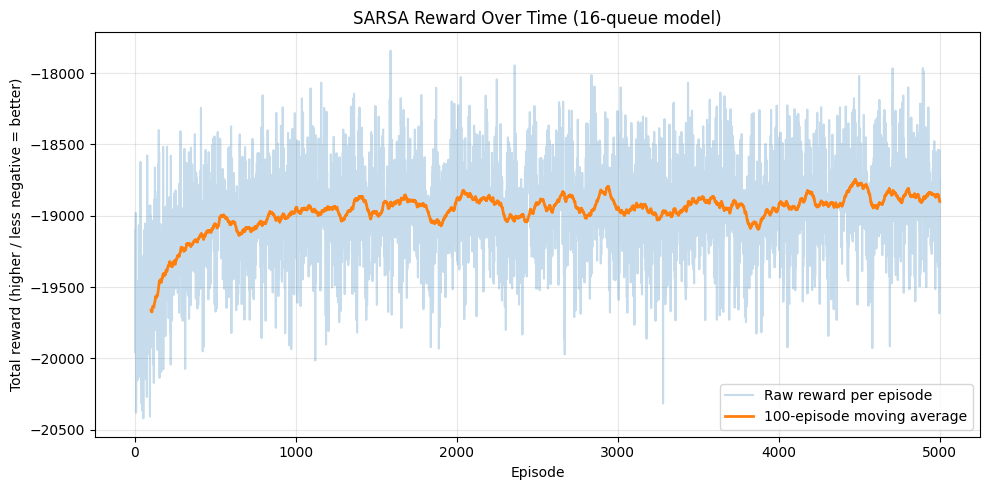

In [7]:
Q_table_sarsa, rewards_sarsa, queue_totals_sarsa = train_sarsa(num_episodes=5000)
plot_learning_curve(rewards_sarsa, window=100, title="SARSA Reward Over Time (16-queue model)")

## **q learning vs sarsa comparison function**

> Add blockquote



In [8]:
import numpy as np
import matplotlib.pyplot as plt


def plot_comparison(
    rewards_dict,
    window=100,
    title="Algorithm Comparison: Reward Over Time"
):
    """
    Plots the moving-average learning curve for multiple algorithms
    on the SAME chart, so they can be compared directly.

    rewards_dict: a dictionary mapping a label (string) to a rewards list.
        Example:
            {
                "Q-Learning": rewards,
                "SARSA": rewards_sarsa
            }

    window: how many episodes to average over for the smoothed line
            (same meaning as in plot_learning_curve)

    Only the smoothed moving-average lines are shown here (no raw/noisy
    lines) -- with multiple algorithms on one chart, raw data from each
    would overlap and make the comparison hard to read. Use
    plot_learning_curve() separately if you want to see one algorithm's
    raw noise in detail.
    """

    plt.figure(figsize=(10, 5))

    for label, episode_rewards in rewards_dict.items():

        episodes = np.arange(1, len(episode_rewards) + 1)

        if len(episode_rewards) >= window:
            moving_avg = np.convolve(
                episode_rewards,
                np.ones(window) / window,
                mode="valid"
            )
            plt.plot(
                episodes[window - 1:],
                moving_avg,
                linewidth=2,
                label=f"{label} ({window}-episode moving avg)"
            )
        else:
            # Not enough episodes to smooth -- just plot raw values
            plt.plot(episodes, episode_rewards, linewidth=2, label=label)

    plt.xlabel("Episode")
    plt.ylabel("Total reward (higher / less negative = better)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def print_comparison_summary(rewards_dict, last_n=500):
    """
    Prints a quick numeric summary comparing final performance
    across algorithms -- useful alongside the plot for a report table.
    """
    print(f"{'Algorithm':<15} | {'Avg reward, first '+str(last_n):<22} | {'Avg reward, last '+str(last_n):<22}")
    print("-" * 65)
    for label, episode_rewards in rewards_dict.items():
        first_avg = np.mean(episode_rewards[:last_n])
        last_avg = np.mean(episode_rewards[-last_n:])
        print(f"{label:<15} | {first_avg:<22.1f} | {last_avg:<22.1f}")





# **Q-learning vs SARSA comparison using the completed 5,000-episode training runs**


Q-learning episodes: 5000
SARSA episodes: 5000


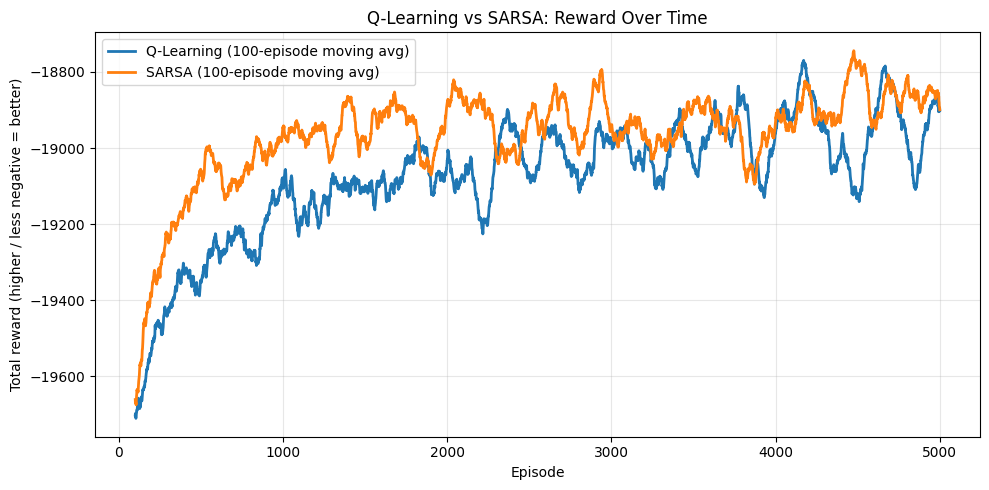

Algorithm       | Avg reward, first 500  | Avg reward, last 500  
-----------------------------------------------------------------
Q-Learning      | -19467.2               | -18923.3              
SARSA           | -19298.1               | -18874.3              


In [9]:
# =============================================================
# COMPARE THE ALREADY-TRAINED Q-LEARNING AND SARSA AGENTS
# =============================================================
#
# Existing 5,000-episode training runs:
#
#     rewards_qlearning -> Q-learning rewards
#     rewards_sarsa     -> SARSA rewards
#
# =============================================================

print("Q-learning episodes:", len(rewards_qlearning))
print("SARSA episodes:", len(rewards_sarsa))

plot_comparison(
    {
        "Q-Learning": rewards_qlearning,
        "SARSA": rewards_sarsa
    },
    window=100,
    title="Q-Learning vs SARSA: Reward Over Time"
)

print_comparison_summary(
    {
        "Q-Learning": rewards_qlearning,
        "SARSA": rewards_sarsa
    }
)


# **Step 5a — Exploration Comparison (Tabular Q-Learning)**

The standard agent uses epsilon-greedy exploration. The alternative below uses Boltzmann/softmax exploration.

```text
EPSILON-GREEDY                     BOLTZMANN / SOFTMAX

random action sometimes            every action gets a probability
        |                                      |
        v                                      v
otherwise choose best              better Q-values get more probability
```
> This subsection covers the **tabular** Q-learning agent only. The equivalent comparison for **DQN** is Step 5b, later in the notebook, not a repeat of this cell.


In [10]:
def train_q_learning_boltzmann(
    num_episodes=2000,
    max_queue_length=20,
    num_buckets=2,
    green_light_capacity=5,
    outgoing_road_capacity=5,
    max_steps=100,
    alpha=0.1,
    gamma=0.9,
    temperature_start=1.0,  # Starting temperature for Boltzmann exploration
    temperature_end=0.1,    # Minimum temperature
    temperature_decay=0.995, # Decay rate for temperature
    use_blocked_penalty=False,
    blocked_penalty_weight=1.0,
    use_fairness_penalty=False,
    fairness_penalty_weight=0.1
):
    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        green_light_capacity=green_light_capacity,
        outgoing_road_capacity=outgoing_road_capacity,
        max_steps=max_steps,
        use_argmax_policy=False,
        use_blocked_penalty=use_blocked_penalty,
        blocked_penalty_weight=blocked_penalty_weight,
        use_fairness_penalty=use_fairness_penalty,
        fairness_penalty_weight=fairness_penalty_weight
    )

    num_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(num_actions))

    temperature = temperature_start
    episode_rewards = []
    episode_queue_totals = []

    for episode in range(num_episodes):
        state, info = env.reset()
        state_key = discretize_state(state, max_queue_length, num_buckets)

        total_reward = 0
        total_queue = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):
            # BOLTZMANN (SOFTMAX) EXPLORATION
            # Convert Q-values to probabilities using softmax with temperature
            q_values = Q[state_key]
            # Avoid division by zero in softmax if all q_values are extremely low
            exp_q_values = np.exp((q_values - np.max(q_values)) / temperature)
            probabilities = exp_q_values / np.sum(exp_q_values)
            action = np.random.choice(num_actions, p=probabilities)

            next_state, reward, terminated, truncated, info = env.step(action)
            next_state_key = discretize_state(next_state, max_queue_length, num_buckets)

            # Do not bootstrap beyond the end of an episode.
            done = terminated or truncated
            best_next_value = 0.0 if done else np.max(Q[next_state_key])
            td_target = reward + gamma * best_next_value
            td_error = td_target - Q[state_key][action]
            Q[state_key][action] += alpha * td_error

            state_key = next_state_key
            total_reward += reward
            total_queue += info["total_system_queue"]

        # Decay temperature after each episode
        temperature = max(temperature_end, temperature * temperature_decay)
        episode_rewards.append(total_reward)
        episode_queue_totals.append(total_queue)

        if (episode + 1) % max(1, num_episodes // 10) == 0:
            recent_avg = np.mean(episode_rewards[-max(1, num_episodes // 10):])
            print(f"Episode {episode+1:>5}/{num_episodes} | "
                  f"temperature={temperature:.3f} | "
                  f"avg reward (last batch)={recent_avg:.1f} | "
                  f"Q-table size={len(Q)} states")

    return Q, episode_rewards, episode_queue_totals

Episode   500/5000 | temperature=0.100 | avg reward (last batch)=-19434.9 | Q-table size=2507 states
Episode  1000/5000 | temperature=0.100 | avg reward (last batch)=-19161.8 | Q-table size=3401 states
Episode  1500/5000 | temperature=0.100 | avg reward (last batch)=-19089.0 | Q-table size=3746 states
Episode  2000/5000 | temperature=0.100 | avg reward (last batch)=-19032.6 | Q-table size=3912 states
Episode  2500/5000 | temperature=0.100 | avg reward (last batch)=-18992.4 | Q-table size=4013 states
Episode  3000/5000 | temperature=0.100 | avg reward (last batch)=-18904.2 | Q-table size=4059 states
Episode  3500/5000 | temperature=0.100 | avg reward (last batch)=-18932.4 | Q-table size=4078 states
Episode  4000/5000 | temperature=0.100 | avg reward (last batch)=-18990.5 | Q-table size=4091 states
Episode  4500/5000 | temperature=0.100 | avg reward (last batch)=-19001.9 | Q-table size=4094 states
Episode  5000/5000 | temperature=0.100 | avg reward (last batch)=-18832.2 | Q-table size=40

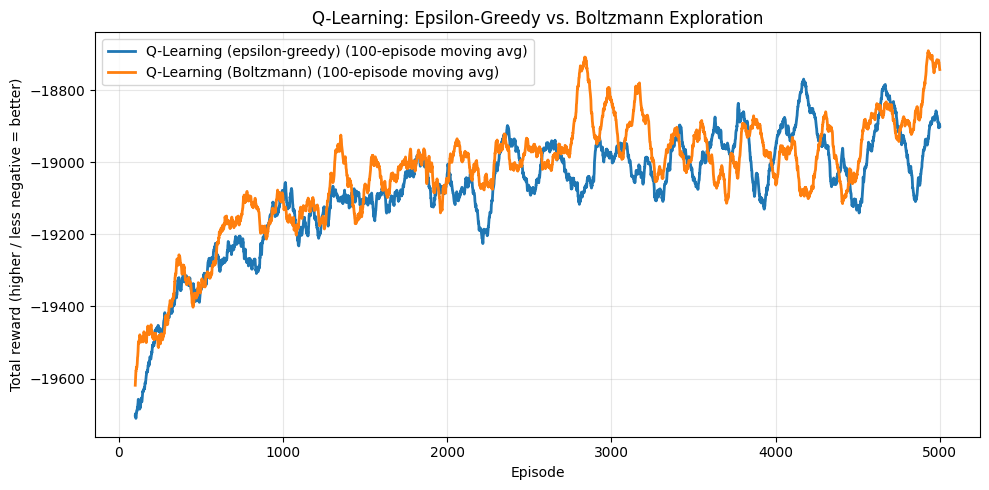

Algorithm       | Avg reward, first 500  | Avg reward, last 500  
-----------------------------------------------------------------
Q-Learning (epsilon-greedy) | -19467.2               | -18923.3              
Q-Learning (Boltzmann) | -19434.9               | -18832.2              


In [11]:
# Train Q-learning with Boltzmann exploration.
Q_boltzmann, rewards_boltzmann, queue_totals_boltzmann = train_q_learning_boltzmann(
    num_episodes=5000
)

print("Epsilon-greedy Q-learning episodes:", len(rewards_qlearning))
print("Boltzmann Q-learning episodes:", len(rewards_boltzmann))

# Compare epsilon-greedy Q-learning with Boltzmann Q-learning.
plot_comparison(
    {
        "Q-Learning (epsilon-greedy)": rewards_qlearning,
        "Q-Learning (Boltzmann)": rewards_boltzmann
    },
    window=100,
    title="Q-Learning: Epsilon-Greedy vs. Boltzmann Exploration"
)

print_comparison_summary(
    {
        "Q-Learning (epsilon-greedy)": rewards_qlearning,
        "Q-Learning (Boltzmann)": rewards_boltzmann
    }
)


# **Step 6 — Study the effects of γ (gamma) and α (alpha)**

This section completes the required hyperparameter study for **both Q-learning and SARSA**.

### What γ controls

```text
SMALL γ                                      LARGE γ
γ = 0.5                                      γ = 0.99

Current reward matters most                  Future congestion matters more
          |                                             |
          v                                             v
  "Fix traffic now"                         "Think several steps ahead"
```

### What α controls

```text
OLD Q-VALUE
    |
    |  receive new experience
    v
TD ERROR = new information
    |
    | multiplied by alpha
    v
UPDATE SIZE

Small alpha  -> slow, cautious updates
Large alpha  -> fast, aggressive updates
```

To keep the comparison fair, each parameter study changes **only one parameter at a time**.

In [12]:
# =============================================================
# STEP 6 HELPER: RUN ONE HYPERPARAMETER STUDY
# =============================================================
#
# This function prevents us from copying the same training code
# twelve times.
#
#                         PARAMETER STUDY
#
#                value 1      value 2      value 3
#                   |            |            |
#                   v            v            v
#               train agent  train agent  train agent
#                   |            |            |
#                   +------------+------------+
#                                |
#                                v
#                     compare final performance
#
# We store:
#
#   1. the full reward curve
#   2. the full cumulative-queue curve
#   3. average reward over the final episodes
#   4. average cumulative queue over the final episodes
#
# A LESS NEGATIVE reward is better.
# A SMALLER cumulative queue is better.
# =============================================================

import pandas as pd


def run_hyperparameter_study(
    train_function,
    algorithm_name,
    parameter_name,
    values,
    num_episodes=3000,
    final_window=500,
    **fixed_kwargs
):
    curves = {}
    queue_curves = {}
    rows = []

    for value in values:

        print("\n" + "=" * 70)
        print(f"{algorithm_name}: testing {parameter_name} = {value}")
        print("=" * 70)

        run_kwargs = dict(fixed_kwargs)
        run_kwargs[parameter_name] = value

        learned_q, rewards_run, queues_run = train_function(
            num_episodes=num_episodes,
            **run_kwargs
        )

        label = f"{algorithm_name} ({parameter_name}={value})"

        curves[label] = rewards_run
        queue_curves[label] = queues_run

        window = min(final_window, len(rewards_run))

        rows.append({
            "Algorithm": algorithm_name,
            "Parameter": parameter_name,
            "Value": value,
            "Final Avg Reward": float(np.mean(rewards_run[-window:])),
            "Final Avg Cumulative Queue": float(np.mean(queues_run[-window:])),
        })

    return curves, queue_curves, pd.DataFrame(rows)


Q-Learning: testing gamma = 0.5
Episode   300/3000 | epsilon=0.222 | avg reward (last batch)=-19540.8 | Q-table size=1541 states
Episode   600/3000 | epsilon=0.050 | avg reward (last batch)=-19316.7 | Q-table size=2216 states
Episode   900/3000 | epsilon=0.050 | avg reward (last batch)=-19184.9 | Q-table size=2690 states
Episode  1200/3000 | epsilon=0.050 | avg reward (last batch)=-19179.0 | Q-table size=3037 states
Episode  1500/3000 | epsilon=0.050 | avg reward (last batch)=-19070.5 | Q-table size=3315 states
Episode  1800/3000 | epsilon=0.050 | avg reward (last batch)=-19137.7 | Q-table size=3514 states
Episode  2100/3000 | epsilon=0.050 | avg reward (last batch)=-19089.0 | Q-table size=3663 states
Episode  2400/3000 | epsilon=0.050 | avg reward (last batch)=-18991.2 | Q-table size=3809 states
Episode  2700/3000 | epsilon=0.050 | avg reward (last batch)=-18979.5 | Q-table size=3892 states
Episode  3000/3000 | epsilon=0.050 | avg reward (last batch)=-19060.4 | Q-table size=3957 stat

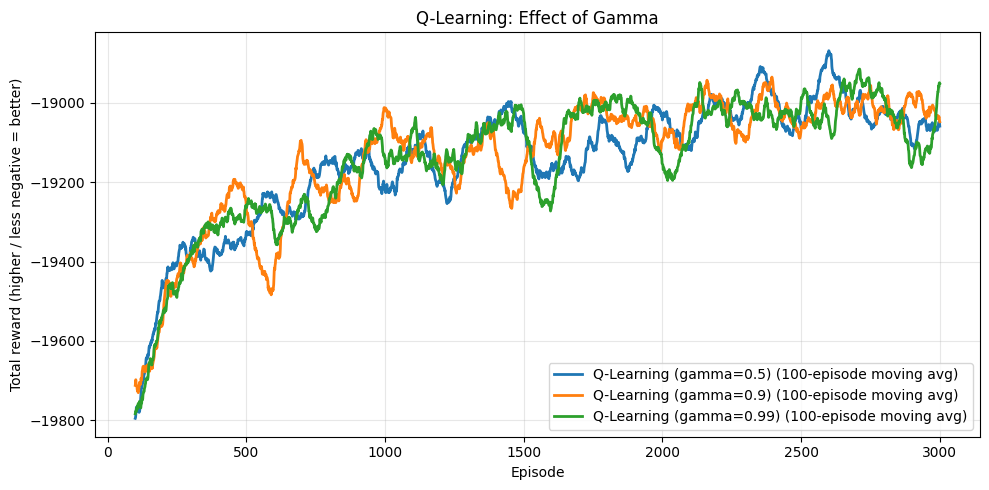

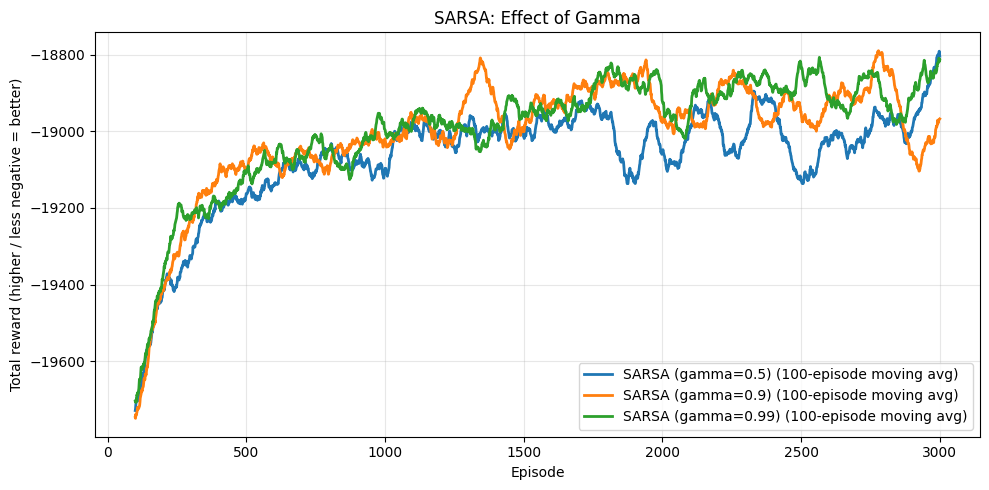


GAMMA STUDY SUMMARY


,Algorithm,Parameter,Value,Final Avg Reward,Final Avg Cumulative Queue
0,Q-Learning,gamma,0.50,-19011.370,19011.370
1,Q-Learning,gamma,0.90,-19007.578,19007.578
2,Q-Learning,gamma,0.99,-19017.146,19017.146
3,SARSA,gamma,0.50,-18967.838,18967.838
4,SARSA,gamma,0.90,-18938.156,18938.156
5,SARSA,gamma,0.99,-18889.510,18889.510


In [13]:
# =============================================================
# STEP 6A: GAMMA STUDY
# =============================================================
#
# Gamma = discount factor
#
#              reward now
#                  +
#          gamma * future value
#
#
# gamma = 0.5
#     |
#     +----> future rewards fade quickly
#
# gamma = 0.9
#     |
#     +----> balanced default
#
# gamma = 0.99
#     |
#     +----> future traffic conditions stay important
#
# =============================================================

GAMMA_VALUES = [0.5, 0.9, 0.99]
TUNING_EPISODES = 3000


q_gamma_rewards, q_gamma_queues, q_gamma_table = run_hyperparameter_study(
    train_function=train_q_learning,
    algorithm_name="Q-Learning",
    parameter_name="gamma",
    values=GAMMA_VALUES,
    num_episodes=TUNING_EPISODES,
    alpha=0.1
)


sarsa_gamma_rewards, sarsa_gamma_queues, sarsa_gamma_table = run_hyperparameter_study(
    train_function=train_sarsa,
    algorithm_name="SARSA",
    parameter_name="gamma",
    values=GAMMA_VALUES,
    num_episodes=TUNING_EPISODES,
    alpha=0.1
)


plot_comparison(
    q_gamma_rewards,
    window=100,
    title="Q-Learning: Effect of Gamma"
)

plot_comparison(
    sarsa_gamma_rewards,
    window=100,
    title="SARSA: Effect of Gamma"
)


gamma_results_table = pd.concat(
    [q_gamma_table, sarsa_gamma_table],
    ignore_index=True
)

print("\nGAMMA STUDY SUMMARY")
display(gamma_results_table)


Q-Learning: testing alpha = 0.01
Episode   300/3000 | epsilon=0.222 | avg reward (last batch)=-19689.5 | Q-table size=1575 states
Episode   600/3000 | epsilon=0.050 | avg reward (last batch)=-19568.6 | Q-table size=2233 states
Episode   900/3000 | epsilon=0.050 | avg reward (last batch)=-19431.4 | Q-table size=2705 states
Episode  1200/3000 | epsilon=0.050 | avg reward (last batch)=-19324.7 | Q-table size=3066 states
Episode  1500/3000 | epsilon=0.050 | avg reward (last batch)=-19347.4 | Q-table size=3352 states
Episode  1800/3000 | epsilon=0.050 | avg reward (last batch)=-19388.5 | Q-table size=3546 states
Episode  2100/3000 | epsilon=0.050 | avg reward (last batch)=-19380.2 | Q-table size=3698 states
Episode  2400/3000 | epsilon=0.050 | avg reward (last batch)=-19400.9 | Q-table size=3817 states
Episode  2700/3000 | epsilon=0.050 | avg reward (last batch)=-19383.2 | Q-table size=3904 states
Episode  3000/3000 | epsilon=0.050 | avg reward (last batch)=-19419.8 | Q-table size=3957 sta

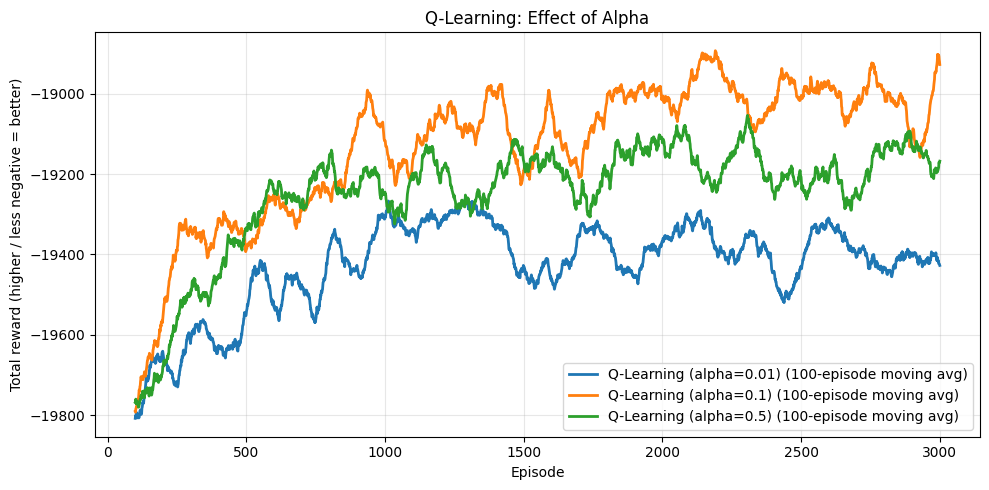

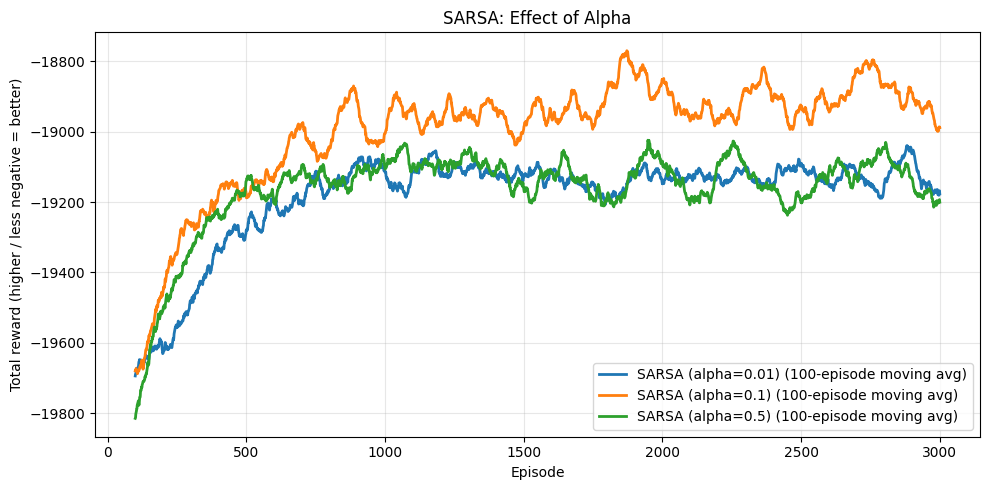


ALPHA STUDY SUMMARY


,Algorithm,Parameter,Value,Final Avg Reward,Final Avg Cumulative Queue
0,Q-Learning,alpha,0.01,-19394.638,19394.638
1,Q-Learning,alpha,0.10,-19006.466,19006.466
2,Q-Learning,alpha,0.50,-19180.036,19180.036
3,SARSA,alpha,0.01,-19131.614,19131.614
4,SARSA,alpha,0.10,-18903.060,18903.060
5,SARSA,alpha,0.50,-19124.790,19124.790


In [14]:
# =============================================================
# STEP 6B: ALPHA STUDY
# =============================================================
#
# Alpha = learning rate
#
#                 TD ERROR
#                    |
#                    v
#
# Q(new) = Q(old) + alpha * TD_ERROR
#
#
# alpha = 0.01
#     |
#     +----> tiny updates, slow learning
#
# alpha = 0.1
#     |
#     +----> moderate updates
#
# alpha = 0.5
#     |
#     +----> large updates, fast but potentially unstable
#
# =============================================================

ALPHA_VALUES = [0.01, 0.1, 0.5]


q_alpha_rewards, q_alpha_queues, q_alpha_table = run_hyperparameter_study(
    train_function=train_q_learning,
    algorithm_name="Q-Learning",
    parameter_name="alpha",
    values=ALPHA_VALUES,
    num_episodes=TUNING_EPISODES,
    gamma=0.9
)


sarsa_alpha_rewards, sarsa_alpha_queues, sarsa_alpha_table = run_hyperparameter_study(
    train_function=train_sarsa,
    algorithm_name="SARSA",
    parameter_name="alpha",
    values=ALPHA_VALUES,
    num_episodes=TUNING_EPISODES,
    gamma=0.9
)


plot_comparison(
    q_alpha_rewards,
    window=100,
    title="Q-Learning: Effect of Alpha"
)

plot_comparison(
    sarsa_alpha_rewards,
    window=100,
    title="SARSA: Effect of Alpha"
)


alpha_results_table = pd.concat(
    [q_alpha_table, sarsa_alpha_table],
    ignore_index=True
)

print("\nALPHA STUDY SUMMARY")
display(alpha_results_table)

### How to interpret Step 6

```text
BEST PARAMETER VALUE
        |
        |  look for
        v
+-------------------------------+
| Higher average reward         |  <- less negative is better
| Lower cumulative queue        |  <- fewer cars waiting is better
| Stable learning curve         |
+-------------------------------+
```

The experiment does **not** assume that one γ or α must always win. The results from the simulation determine which setting works best for this traffic environment.

# **Step 7 — Deep Q-Network (DQN)**

The original project checklist refers to a **12-dimensional state**, but this implementation was extended with four outgoing-road queues. Therefore the current DQN correctly uses the full **16-dimensional non-discretized state**:

```text
12 incoming movement queues
            +
4 outgoing road queues
            =
16 exact queue values
            |
            v
      DQN neural network
            |
            v
      12 action Q-values
```

The DQN does **not** call `discretize_state()`. It learns from the exact queue values.

# **Deep Q-Network (DQN)**

Unlike Q-learning and SARSA, DQN does not store a separate Q-table entry for every state.

Instead, a neural network receives the full 16-value traffic state:

- 12 incoming movement queues
- 4 outgoing road queues

The network produces 12 Q-values, one for each possible traffic movement action.

The action with the largest predicted Q-value is considered the best action.

DQN also uses:

1. **Experience replay** — past transitions are stored and randomly sampled during training.
2. **Target network** — a second neural network provides more stable Q-learning targets.
3. **Epsilon-greedy exploration** — the agent initially explores randomly and gradually relies more on the neural network.

# **DQN**

In [15]:
import numpy as np
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim


# =============================================================
# DQN NEURAL NETWORK
# =============================================================
#
# INPUT:
#
# 16 traffic queue values
#
# [
#   N_W, N_S, N_E,
#   S_W, S_N, S_E,
#   E_N, E_S, E_W,
#   W_N, W_S, W_E,
#   N_N, S_S, E_E, W_W
# ]
#
#
# OUTPUT:
#
# 12 Q-values
#
# One predicted value for each possible action:
#
# 0  -> N_W
# 1  -> N_S
# 2  -> N_E
#
# ...
#
# 11 -> W_E
#
#
#                    16 STATE VALUES
#                          │
#                          ▼
#                   ┌─────────────┐
#                   │ Neural      │
#                   │ Network     │
#                   └─────────────┘
#                          │
#                          ▼
#
#       [Q(N_W), Q(N_S), Q(N_E), ..., Q(W_E)]
#
#                          │
#                          ▼
#               Choose highest Q-value
#
# =============================================================


class DQN(nn.Module):

    def __init__(
        self,
        state_size=16,
        action_size=12
    ):

        super().__init__()


        # -----------------------------------------------------
        # FULLY CONNECTED NEURAL NETWORK
        # -----------------------------------------------------
        #
        # 16 inputs
        #     ↓
        # 128 hidden neurons
        #     ↓
        # 128 hidden neurons
        #     ↓
        # 12 output Q-values
        #
        # -----------------------------------------------------

        self.network = nn.Sequential(

            nn.Linear(
                state_size,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                action_size
            )
        )


    def forward(self, state):

        return self.network(state)

# **Experience replay buffer**

In [16]:
# =============================================================
# EXPERIENCE REPLAY BUFFER
# =============================================================
#
# During training, the DQN stores experiences:
#
#        state
#          ↓
#        action
#          ↓
#        reward
#          ↓
#      next_state
#          ↓
#         done
#
#
# Example transition:
#
# State:
# [3, 8, 2, ..., 1, 0, 2, 1]
#
# Action:
# N_S
#
# Reward:
# -54
#
# Next state:
# [4, 4, 3, ..., 2, 0, 2, 1]
#
#
# These experiences are stored in memory.
#
# Instead of learning only from the newest experience,
# DQN randomly samples old experiences from memory.
#
# This makes neural-network training more stable.
#
# =============================================================


class ReplayBuffer:

    def __init__(
        self,
        capacity=50000
    ):

        self.buffer = deque(
            maxlen=capacity
        )


    def add(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        self.buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )


    def sample(
        self,
        batch_size
    ):

        batch = random.sample(
            self.buffer,
            batch_size
        )


        states = np.array(
            [
                transition[0]
                for transition in batch
            ],
            dtype=np.float32
        )


        actions = np.array(
            [
                transition[1]
                for transition in batch
            ],
            dtype=np.int64
        )


        rewards = np.array(
            [
                transition[2]
                for transition in batch
            ],
            dtype=np.float32
        )


        next_states = np.array(
            [
                transition[3]
                for transition in batch
            ],
            dtype=np.float32
        )


        dones = np.array(
            [
                transition[4]
                for transition in batch
            ],
            dtype=np.float32
        )


        return (
            states,
            actions,
            rewards,
            next_states,
            dones
        )


    def __len__(self):

        return len(self.buffer)

In [17]:
# =============================================================
# DQN TRAINING FUNCTION
# =============================================================
#
# Orchestrates the entire training process for the DQN agent:
#
# 1. Environment setup.
# 2. DQN and Target networks initialization.
# 3. Optimizer and loss function setup.
# 4. Epsilon-greedy action selection.
# 5. Experience replay.
# 6. Periodic target network updates.
#
# Returns the trained model, episode rewards, episode queue totals,
# and a list of losses during training.
#
# =============================================================

def train_dqn(
    num_episodes=2000,
    max_queue_length=20,
    green_light_capacity=5,
    outgoing_road_capacity=5,
    max_steps=100,
    gamma=0.9,           # Discount factor
    epsilon_start=1.0,   # Starting exploration rate
    epsilon_end=0.05,    # Minimum exploration rate
    epsilon_decay=0.995, # Decay rate for epsilon
    lr=0.001,            # Learning rate for the optimizer
    batch_size=64,       # Size of experience batches sampled from replay buffer
    target_update_freq=10, # How often to update the target network (in episodes)
    replay_buffer_capacity=50000,
    use_blocked_penalty=False,
    blocked_penalty_weight=1.0,
    use_fairness_penalty=False,
    fairness_penalty_weight=0.1
):
    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        green_light_capacity=green_light_capacity,
        outgoing_road_capacity=outgoing_road_capacity,
        max_steps=max_steps,
        use_argmax_policy=False,
        use_blocked_penalty=use_blocked_penalty,
        blocked_penalty_weight=blocked_penalty_weight,
        use_fairness_penalty=use_fairness_penalty,
        fairness_penalty_weight=fairness_penalty_weight
    )

    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    # Initialize main and target DQN networks
    policy_net = DQN(state_size, action_size)
    target_net = DQN(state_size, action_size)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval() # Set target network to evaluation mode

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    criterion = nn.MSELoss()
    replay_buffer = ReplayBuffer(replay_buffer_capacity)

    epsilon = epsilon_start
    episode_rewards = []
    episode_queue_totals = []
    losses = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        # Normalize all 16 queue values from 0-20 into roughly 0-1.
        #
        #     raw state:         [0 ... 20]
        #                              |
        #                              v
        #     normalized state: [0 ... 1]
        #
        # This usually makes neural-network optimization more stable.
        state = torch.tensor(
            state / max_queue_length,
            dtype=torch.float32
        ).unsqueeze(0)

        total_reward = 0
        total_queue = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):
            # Epsilon-greedy action selection
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad(): # No need to track gradients for action selection
                    action = policy_net(state).argmax().item()

            next_state, reward, terminated, truncated, info = env.step(action)
            next_state = torch.tensor(
                next_state / max_queue_length,
                dtype=torch.float32
            ).unsqueeze(0)
            done = terminated or truncated

            # Store experience in replay buffer
            replay_buffer.add(
                state.squeeze(0).numpy(), # Remove batch dimension for storage
                action,
                reward,
                next_state.squeeze(0).numpy(),
                done
            )

            state = next_state
            total_reward += reward
            total_queue += info["total_system_queue"]

            # Perform a learning step if buffer has enough samples
            if len(replay_buffer) > batch_size:
                states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                # Convert to tensors
                states = torch.tensor(states, dtype=torch.float32)
                actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
                rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
                next_states = torch.tensor(next_states, dtype=torch.float32)
                dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

                # Compute Q-values for current states (from policy_net)
                current_q_values = policy_net(states).gather(1, actions)

                # Compute target Q-values (from target_net)
                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1)[0].unsqueeze(1)
                    target_q_values = rewards + (1 - dones) * gamma * next_q_values

                # Compute loss and update policy_net
                loss = criterion(current_q_values, target_q_values)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                losses.append(loss.item())

        # Decay epsilon
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)
        episode_queue_totals.append(total_queue)

        # Update target network periodically
        if (episode + 1) % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if (episode + 1) % max(1, num_episodes // 10) == 0:
            recent_avg_reward = np.mean(episode_rewards[-max(1, num_episodes // 10):])
            recent_avg_loss = np.mean(losses[-max(1, len(losses) // 10):]) if losses else 0
            print(f"Episode {episode+1:>5}/{num_episodes} | "
                  f"epsilon={epsilon:.3f} | "
                  f"avg reward (last batch)={recent_avg_reward:.1f} | "
                  f"avg loss (last batch)={recent_avg_loss:.4f} | "
                  f"buffer size={len(replay_buffer)} transitions")

    return policy_net, episode_rewards, episode_queue_totals, losses

# **Smoke-test cell**

In [18]:
# =============================================================
# QUICK DQN SMOKE TEST
# =============================================================
#
# ill Run a shorter training test first.
#
# DQN usually needs more experience than the tabular methods,
# so let's not expect 200 episodes to give a fully trained agent.
#
# This is mainly checking that the code runs correctly.
#
# =============================================================


dqn_model, dqn_rewards, dqn_queue_totals, dqn_losses = train_dqn(

    num_episodes=200

)


print(
    "\nAverage reward, first 20 episodes:",
    round(
        np.mean(
            dqn_rewards[:20]
        ),
        1
    )
)


print(
    "Average reward, last 20 episodes:",
    round(
        np.mean(
            dqn_rewards[-20:]
        ),
        1
    )
)


print(
    "Number of neural-network updates:",
    len(
        dqn_losses
    )
)

Episode    20/200 | epsilon=0.905 | avg reward (last batch)=-19986.5 | avg loss (last batch)=452.3878 | buffer size=2000 transitions
Episode    40/200 | epsilon=0.818 | avg reward (last batch)=-19839.7 | avg loss (last batch)=2884.7284 | buffer size=4000 transitions
Episode    60/200 | epsilon=0.740 | avg reward (last batch)=-19591.0 | avg loss (last batch)=5324.3350 | buffer size=6000 transitions
Episode    80/200 | epsilon=0.670 | avg reward (last batch)=-19625.5 | avg loss (last batch)=9151.6087 | buffer size=8000 transitions
Episode   100/200 | epsilon=0.606 | avg reward (last batch)=-19464.5 | avg loss (last batch)=13720.0854 | buffer size=10000 transitions
Episode   120/200 | epsilon=0.548 | avg reward (last batch)=-19316.9 | avg loss (last batch)=14991.6214 | buffer size=12000 transitions
Episode   140/200 | epsilon=0.496 | avg reward (last batch)=-19381.7 | avg loss (last batch)=17261.6941 | buffer size=14000 transitions
Episode   160/200 | epsilon=0.448 | avg reward (last batc

# Q-LEARNING / SARSA
16 queues
    ->
Discretize into Low / High
    ->
Use Q-table






# DQN
 16 queues
#    ↓
 Normalize exact values
#    ↓
 Neural network
#    ↓
 12 Q-values

In [19]:
dqn_model, dqn_rewards, dqn_queue_totals, dqn_losses = train_dqn(

    num_episodes=5000

)

Episode   500/5000 | epsilon=0.082 | avg reward (last batch)=-19642.2 | avg loss (last batch)=24587.6540 | buffer size=50000 transitions
Episode  1000/5000 | epsilon=0.050 | avg reward (last batch)=-19848.8 | avg loss (last batch)=24883.9889 | buffer size=50000 transitions
Episode  1500/5000 | epsilon=0.050 | avg reward (last batch)=-19826.5 | avg loss (last batch)=25016.6515 | buffer size=50000 transitions
Episode  2000/5000 | epsilon=0.050 | avg reward (last batch)=-19606.8 | avg loss (last batch)=22828.7312 | buffer size=50000 transitions
Episode  2500/5000 | epsilon=0.050 | avg reward (last batch)=-19526.3 | avg loss (last batch)=23093.0310 | buffer size=50000 transitions
Episode  3000/5000 | epsilon=0.050 | avg reward (last batch)=-19576.1 | avg loss (last batch)=23114.0942 | buffer size=50000 transitions
Episode  3500/5000 | epsilon=0.050 | avg reward (last batch)=-19287.3 | avg loss (last batch)=23062.6208 | buffer size=50000 transitions
Episode  4000/5000 | epsilon=0.050 | avg 

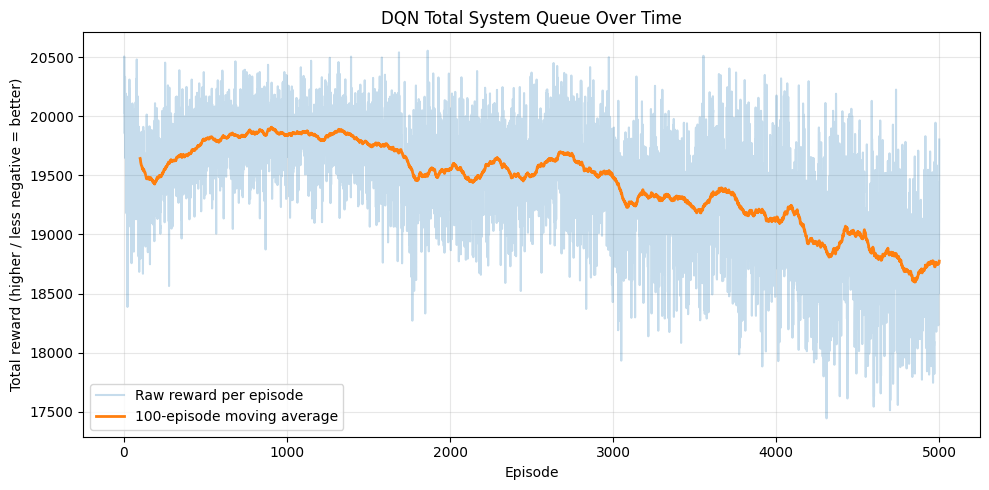

In [20]:
plot_learning_curve(dqn_queue_totals, window=100, title="DQN Total System Queue Over Time")

# **Step 8a — Preliminary Evaluation (exploratory, pre-reproducibility pass)**

> **Status: superseded by Step 8b.** This evaluation uses the policies trained earlier in the notebook (Steps 2-4, DQN in Step 7) **before** the fixed-seed reproducibility pass was added. It is kept for transparency / development history, but the canonical numbers used in the paper and slide deck are from **Step 8b**, not this cell.

The fairest final comparison is **not** to compare their training rewards directly, because Q-learning, SARSA, and DQN are still exploring during training.

Instead, all four finished policies are evaluated with exploration turned off.

```text
             SAME EVALUATION EPISODE SEEDS
                         |
          +--------------+--------------+
          |              |              |
          v              v              v
      Baseline       Q-Learning       SARSA          DQN
          |              |              |              |
          +--------------+--------------+--------------+
                         |
                         v
             SAME ENVIRONMENT SETTINGS
                         |
                         v
              COMPARE THE SAME METRICS
```

Metrics:

- **Average reward per episode** — higher / less negative is better.
- **Average cumulative system queue per episode** — lower is better.
- **Average queue per step** — lower is better.

In [21]:
# =============================================================
# STEP 8: FAIR EVALUATION FUNCTIONS
# =============================================================
#
# IMPORTANT:
#
# During TRAINING:
#
#     Q-learning / SARSA / DQN sometimes choose random actions
#     because they are exploring.
#
# During FINAL EVALUATION:
#
#     exploration = OFF
#
#
#             CURRENT STATE
#                  |
#       +----------+----------+
#       |          |          |
#       v          v          v
#   Q-table      Q-table     Neural net
#  Q-learning     SARSA         DQN
#       |          |             |
#       v          v             v
#   argmax Q    argmax Q      argmax Q
#
#
# Baseline does not use learned values:
#
#   12 incoming queues
#           |
#           v
#   choose largest queue
#
# Every method is tested using the same sequence of episode seeds.
# That gives each method comparable initial traffic and arrival
# randomness.
# =============================================================


def evaluate_baseline(
    num_episodes=200,
    seed_start=10000,
    max_queue_length=20,
    green_light_capacity=5,
    outgoing_road_capacity=5,
    max_steps=100
):
    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        green_light_capacity=green_light_capacity,
        outgoing_road_capacity=outgoing_road_capacity,
        max_steps=max_steps,
        use_argmax_policy=True
    )

    rewards = []
    cumulative_queues = []

    for episode in range(num_episodes):

        state, _ = env.reset(seed=seed_start + episode)

        total_reward = 0.0
        total_queue = 0.0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            # The action is ignored in baseline mode.
            # The environment itself chooses the largest incoming queue.
            action_placeholder = 0

            state, reward, terminated, truncated, info = env.step(
                action_placeholder
            )

            total_reward += reward
            total_queue += info["total_system_queue"]

        rewards.append(total_reward)
        cumulative_queues.append(total_queue)

    env.close()

    return rewards, cumulative_queues


def evaluate_tabular_policy(
    Q,
    num_episodes=200,
    seed_start=10000,
    max_queue_length=20,
    num_buckets=2,
    green_light_capacity=5,
    outgoing_road_capacity=5,
    max_steps=100
):
    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        green_light_capacity=green_light_capacity,
        outgoing_road_capacity=outgoing_road_capacity,
        max_steps=max_steps,
        use_argmax_policy=False
    )

    rewards = []
    cumulative_queues = []

    for episode in range(num_episodes):

        state, _ = env.reset(seed=seed_start + episode)

        total_reward = 0.0
        total_queue = 0.0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            # Exact 16-value state
            #          |
            #          v
            # Low/High discretization
            #          |
            #          v
            # Lookup 12 Q-values
            #          |
            #          v
            # Choose largest Q-value
            state_key = discretize_state(
                state,
                max_queue_length=max_queue_length,
                num_buckets=num_buckets
            )

            # If a state was never visited during training, all actions
            # are treated as equally unknown (all zeros).
            q_values = Q.get(
                state_key,
                np.zeros(env.action_space.n)
            )

            action = int(np.argmax(q_values))

            state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            total_queue += info["total_system_queue"]

        rewards.append(total_reward)
        cumulative_queues.append(total_queue)

    env.close()

    return rewards, cumulative_queues


def evaluate_dqn_policy(
    model,
    num_episodes=200,
    seed_start=10000,
    max_queue_length=20,
    green_light_capacity=5,
    outgoing_road_capacity=5,
    max_steps=100
):
    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        green_light_capacity=green_light_capacity,
        outgoing_road_capacity=outgoing_road_capacity,
        max_steps=max_steps,
        use_argmax_policy=False
    )

    rewards = []
    cumulative_queues = []

    # Use the same device on which the model currently lives.
    device = next(model.parameters()).device
    model.eval()

    for episode in range(num_episodes):

        state, _ = env.reset(seed=seed_start + episode)

        total_reward = 0.0
        total_queue = 0.0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            # -------------------------------------------------
            # DQN ACTION FLOW
            #
            # 16 exact queue values
            #          |
            #          v
            # normalize from 0-20 to 0-1
            #          |
            #          v
            # neural network
            #          |
            #          v
            # 12 predicted Q-values
            #          |
            #          v
            # argmax -> selected traffic movement
            # -------------------------------------------------

            normalized_state = (
                state.astype(np.float32)
                / max_queue_length
            )

            state_tensor = torch.tensor(
                normalized_state,
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            with torch.no_grad():
                q_values = model(state_tensor)

            action = int(torch.argmax(q_values, dim=1).item())

            state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            total_queue += info["total_system_queue"]

        rewards.append(total_reward)
        cumulative_queues.append(total_queue)

    env.close()

    return rewards, cumulative_queues

In [22]:
# =============================================================
# RUN THE FINAL FOUR-WAY COMPARISON
# =============================================================
#
# Required trained objects from earlier cells:
#
#   Q_qlearning     -> trained 5,000-episode Q-learning table
#   Q_table_sarsa   -> trained SARSA table
#   dqn_model       -> trained DQN policy network
#
#
# SAME 200 EVALUATION EPISODES
#              |
#      same seed for episode 1
#      same seed for episode 2
#      ...
#      same seed for episode 200
#              |
#              v
#     comparable traffic scenarios
#
# =============================================================

EVALUATION_EPISODES = 200
EVALUATION_SEED_START = 10000
EVALUATION_MAX_STEPS = 100


baseline_eval_rewards, baseline_eval_queues = evaluate_baseline(
    num_episodes=EVALUATION_EPISODES,
    seed_start=EVALUATION_SEED_START,
    max_steps=EVALUATION_MAX_STEPS
)


q_eval_rewards, q_eval_queues = evaluate_tabular_policy(
    Q_qlearning,
    num_episodes=EVALUATION_EPISODES,
    seed_start=EVALUATION_SEED_START,
    max_steps=EVALUATION_MAX_STEPS
)


sarsa_eval_rewards, sarsa_eval_queues = evaluate_tabular_policy(
    Q_table_sarsa,
    num_episodes=EVALUATION_EPISODES,
    seed_start=EVALUATION_SEED_START,
    max_steps=EVALUATION_MAX_STEPS
)


dqn_eval_rewards, dqn_eval_queues = evaluate_dqn_policy(
    dqn_model,
    num_episodes=EVALUATION_EPISODES,
    seed_start=EVALUATION_SEED_START,
    max_steps=EVALUATION_MAX_STEPS
)


final_results = pd.DataFrame([
    {
        "Algorithm": "Baseline (Longest Queue First)",
        "Average Reward / Episode": np.mean(baseline_eval_rewards),
        "Average Cumulative Queue / Episode": np.mean(baseline_eval_queues),
        "Average Queue / Step": np.mean(baseline_eval_queues) / EVALUATION_MAX_STEPS,
    },
    {
        "Algorithm": "Q-Learning",
        "Average Reward / Episode": np.mean(q_eval_rewards),
        "Average Cumulative Queue / Episode": np.mean(q_eval_queues),
        "Average Queue / Step": np.mean(q_eval_queues) / EVALUATION_MAX_STEPS,
    },
    {
        "Algorithm": "SARSA",
        "Average Reward / Episode": np.mean(sarsa_eval_rewards),
        "Average Cumulative Queue / Episode": np.mean(sarsa_eval_queues),
        "Average Queue / Step": np.mean(sarsa_eval_queues) / EVALUATION_MAX_STEPS,
    },
    {
        "Algorithm": "DQN",
        "Average Reward / Episode": np.mean(dqn_eval_rewards),
        "Average Cumulative Queue / Episode": np.mean(dqn_eval_queues),
        "Average Queue / Step": np.mean(dqn_eval_queues) / EVALUATION_MAX_STEPS,
    },
])


# Higher reward is better, so sort from highest to lowest reward.
final_results = final_results.sort_values(
    "Average Reward / Episode",
    ascending=False
).reset_index(drop=True)


print("\nFINAL EVALUATION RESULTS")
print("=" * 80)
display(final_results)


FINAL EVALUATION RESULTS


,Algorithm,Average Reward / Episode,Average Cumulative Queue / Episode,Average Queue / Step
0,DQN,-17374.645,17374.645,173.74645
1,Q-Learning,-18688.805,18688.805,186.88805
2,SARSA,-19083.200,19083.200,190.83200
3,Baseline (Longest Queue First),-20559.205,20559.205,205.59205


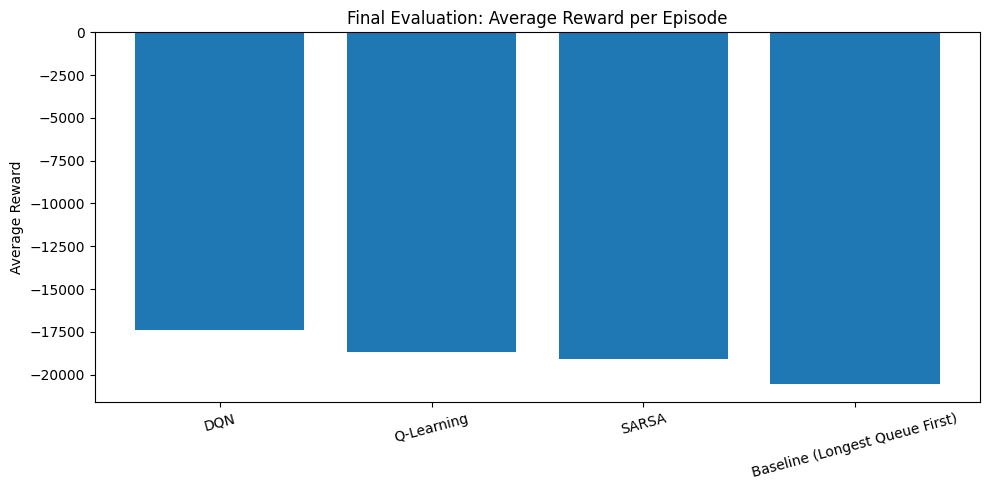

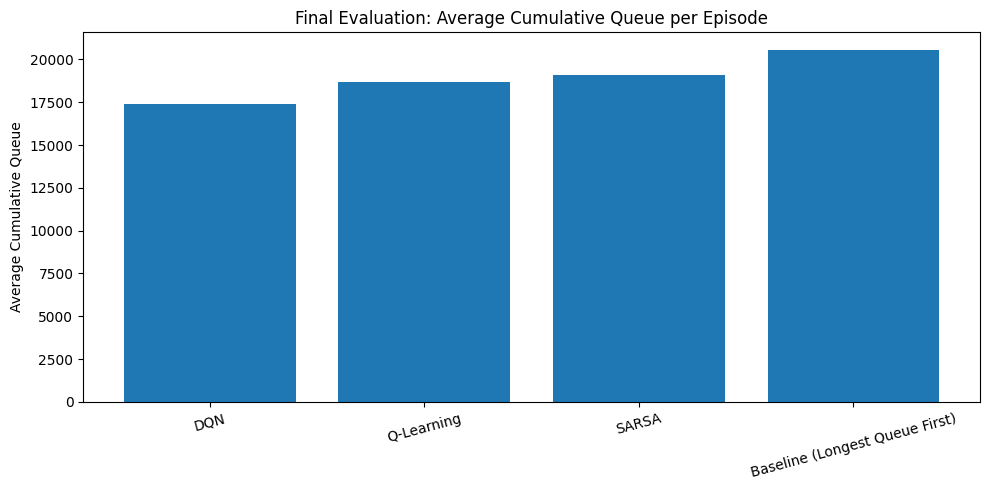

In [23]:
# =============================================================
# FINAL REPORT CHARTS
# =============================================================
#
# CHART 1:
#
# Average reward
#
# Less negative / higher
#         =
# Better
#
#
# CHART 2:
#
# Average cumulative queue
#
# Smaller
#    =
# Better
# =============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.bar(
    final_results["Algorithm"],
    final_results["Average Reward / Episode"]
)
plt.title("Final Evaluation: Average Reward per Episode")
plt.ylabel("Average Reward")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(
    final_results["Algorithm"],
    final_results["Average Cumulative Queue / Episode"]
)
plt.title("Final Evaluation: Average Cumulative Queue per Episode")
plt.ylabel("Average Cumulative Queue")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Final comparison interpretation

```text
RESULT TABLE
    |
    +---- Average Reward / Episode
    |          |
    |          +---- HIGHER (less negative) = better
    |
    +---- Average Cumulative Queue / Episode
    |          |
    |          +---- LOWER = better
    |
    +---- Average Queue / Step
               |
               +---- LOWER = better
```

Use the actual table produced by the notebook to state which controller performed best. This avoids claiming a winner before all algorithms are evaluated under identical conditions.
---

### Reconciliation with Step 8b

The table above (Step 8a) and the table in Step 8b report **different DQN, Q-learning, and SARSA numbers** even though both are labeled "final comparison." This is because they evaluate **two different sets of trained policies**:

| | Step 8a (this section) | Step 8b (canonical) |
|---|---|---|
| Policies evaluated | `Q_qlearning`, `Q_table_sarsa`, `dqn_model` - trained in Steps 2-4/7, no fixed seed | `Q_clean_final`, `Q_sarsa_clean_final`, `dqn_clean_final` - retrained in Step 7 with `seed=42` |
| Purpose | Early sanity check that the four-way comparison pipeline works | Reported, reproducible result |
| Baseline row | Identical in both (baseline has no learned parameters, so it is seed-independent) | Identical in both |

Because Q-learning, SARSA, and DQN training is stochastic (exploration order, minibatch sampling, replay-buffer contents), two independently-trained runs of the *same* algorithm land at slightly different final policies even when the average behavior is similar. The baseline row matches exactly between the two tables (it has no trainable parameters), which confirms the environment itself did not change - only the trained policies did.

**Step 8b is the number reported in the paper, slides, and abstract.** Step 8a is retained only as a development-history artifact.


# **Final Completion Pass — Reproducibility and Remaining Requirements**

The earlier sections contain the development history and original training runs.  
The cells below complete the remaining checklist items using **fixed random seeds** and a consistent experiment interface.

```text
                    REPRODUCIBLE EXPERIMENT

                         seed = 42
                             |
            +----------------+----------------+
            |                |                |
            v                v                v
       NumPy RNG         Python RNG       PyTorch RNG
            |                |                |
            +----------------+----------------+
                             |
                             v
               same experiment configuration
                             |
                             v
                   repeatable comparison
```

In [24]:
# =============================================================
# REPRODUCIBILITY HELPERS
# =============================================================
#
# The assignment requires fixed random seeds.
#
# One seed is used to control:
#
#       NumPy random choices
#              +
#       Python random choices
#              +
#       PyTorch initialization / sampling
#
# Each episode also receives a deterministic environment seed:
#
#       episode 0 -> seed + 0
#       episode 1 -> seed + 1
#       episode 2 -> seed + 2
#                    ...
#
# =============================================================

GLOBAL_SEED = 42


def set_global_seed(seed=GLOBAL_SEED):
    import random
    import numpy as np

    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        # These settings favor reproducibility when supported.
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except Exception:
            pass

    except ImportError:
        pass


set_global_seed(GLOBAL_SEED)

print("Global random seed set to:", GLOBAL_SEED)

Global random seed set to: 42


## **Reproducible tabular trainer used for final experiments**

This single function can train either Q-learning or SARSA and can use either epsilon-greedy or Boltzmann exploration.

```text
                         TABULAR TRAINER
                               |
                 +-------------+-------------+
                 |                           |
                 v                           v
             Q-LEARNING                    SARSA
         off-policy target            on-policy target
                 |                           |
                 +-------------+-------------+
                               |
                 +-------------+-------------+
                 |                           |
                 v                           v
          EPSILON-GREEDY                BOLTZMANN
```

In [25]:
# =============================================================
# FINAL REPRODUCIBLE TABULAR TRAINER
# =============================================================

from collections import defaultdict
import numpy as np


def train_tabular_final(
    algorithm="q_learning",
    exploration="epsilon_greedy",
    num_episodes=5000,
    seed=GLOBAL_SEED,
    max_queue_length=20,
    num_buckets=2,
    green_light_capacity=5,
    outgoing_road_capacity=5,
    max_steps=100,
    alpha=0.1,
    gamma=0.9,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
    temperature_start=1.0,
    temperature_end=0.1,
    temperature_decay=0.995,
    use_sensor_noise=False,
    sensor_noise_range=1,
    use_blocked_penalty=False,
    blocked_penalty_weight=1.0,
    use_fairness_penalty=False,
    fairness_penalty_weight=0.1
):
    """
    Final reproducible trainer for Q-learning and SARSA.

    algorithm:
        "q_learning" or "sarsa"

    exploration:
        "epsilon_greedy" or "boltzmann"

    Returns:
        Q-table,
        reward per episode,
        cumulative queue per episode
    """

    if algorithm not in {"q_learning", "sarsa"}:
        raise ValueError("algorithm must be 'q_learning' or 'sarsa'")

    if exploration not in {"epsilon_greedy", "boltzmann"}:
        raise ValueError("exploration must be 'epsilon_greedy' or 'boltzmann'")

    set_global_seed(seed)

    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        green_light_capacity=green_light_capacity,
        outgoing_road_capacity=outgoing_road_capacity,
        max_steps=max_steps,
        use_argmax_policy=False,
        use_sensor_noise=use_sensor_noise,
        sensor_noise_range=sensor_noise_range,
        use_blocked_penalty=use_blocked_penalty,
        blocked_penalty_weight=blocked_penalty_weight,
        use_fairness_penalty=use_fairness_penalty,
        fairness_penalty_weight=fairness_penalty_weight
    )

    num_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(num_actions, dtype=np.float64))

    epsilon = epsilon_start
    temperature = temperature_start

    episode_rewards = []
    episode_queue_totals = []

    def choose_action(state_key):
        q_values = Q[state_key]

        # -----------------------------------------------------
        # EPSILON-GREEDY
        #
        #             random action
        #                  ^
        #                  | probability epsilon
        #
        # state -> Q values +----------------------> action
        #                  |
        #                  | probability 1-epsilon
        #                  v
        #             best known action
        # -----------------------------------------------------
        if exploration == "epsilon_greedy":
            if np.random.random() < epsilon:
                return env.action_space.sample()
            return int(np.argmax(q_values))

        # -----------------------------------------------------
        # BOLTZMANN / SOFTMAX
        #
        # Q VALUES
        #    |
        #    v
        # convert to probabilities
        #    |
        #    v
        # better actions get higher probability,
        # but weaker actions can still be explored
        # -----------------------------------------------------
        scaled = (q_values - np.max(q_values)) / max(temperature, 1e-8)
        exp_values = np.exp(scaled)
        probabilities = exp_values / np.sum(exp_values)

        return int(
            np.random.choice(
                num_actions,
                p=probabilities
            )
        )

    for episode in range(num_episodes):

        # Deterministic episode seed for reproducibility.
        state, _ = env.reset(seed=seed + episode)

        state_key = discretize_state(
            state,
            max_queue_length=max_queue_length,
            num_buckets=num_buckets
        )

        total_reward = 0.0
        total_queue = 0.0
        terminated = False
        truncated = False

        # SARSA commits to its first action before stepping.
        if algorithm == "sarsa":
            action = choose_action(state_key)

        while not (terminated or truncated):

            if algorithm == "q_learning":
                action = choose_action(state_key)

            next_state, reward, terminated, truncated, info = env.step(action)

            next_state_key = discretize_state(
                next_state,
                max_queue_length=max_queue_length,
                num_buckets=num_buckets
            )

            done = terminated or truncated

            if algorithm == "q_learning":

                # =============================================
                # Q-LEARNING TARGET
                #
                #          next state
                #              |
                #              v
                #       look at ALL actions
                #              |
                #              v
                #       choose MAXIMUM value
                #
                # Q-learning learns toward the best possible
                # next action, even if its behavior policy may
                # still explore.
                # =============================================

                future_value = (
                    0.0
                    if done
                    else float(np.max(Q[next_state_key]))
                )

                td_target = reward + gamma * future_value

            else:

                # =============================================
                # SARSA TARGET
                #
                #          next state
                #              |
                #              v
                # choose the ACTUAL next action
                # using the same exploration policy
                #              |
                #              v
                #      learn from that action
                #
                # This includes the risk created by continued
                # exploration, making SARSA on-policy.
                # =============================================

                if done:
                    next_action = None
                    td_target = reward

                else:
                    next_action = choose_action(next_state_key)

                    td_target = (
                        reward
                        + gamma * Q[next_state_key][next_action]
                    )

            td_error = td_target - Q[state_key][action]

            Q[state_key][action] += alpha * td_error

            state_key = next_state_key

            if algorithm == "sarsa" and not done:
                action = next_action

            total_reward += reward
            total_queue += info["total_system_queue"]

        epsilon = max(
            epsilon_end,
            epsilon * epsilon_decay
        )

        temperature = max(
            temperature_end,
            temperature * temperature_decay
        )

        episode_rewards.append(total_reward)
        episode_queue_totals.append(total_queue)

        if (episode + 1) % max(1, num_episodes // 10) == 0:

            recent_window = max(
                1,
                num_episodes // 10
            )

            recent_avg = np.mean(
                episode_rewards[-recent_window:]
            )

            print(
                f"{algorithm:>10} | "
                f"{exploration:>15} | "
                f"episode {episode + 1:>5}/{num_episodes} | "
                f"avg reward={recent_avg:.1f} | "
                f"states={len(Q)}"
            )

    env.close()

    return (
        Q,
        episode_rewards,
        episode_queue_totals
    )

# **Step 5b — Exploration Comparison (DQN)**

Step 5a compared epsilon-greedy and Boltzmann exploration for **tabular** Q-learning. This subsection runs the same comparison for **DQN**, which uses function approximation instead of a Q-table. It is a continuation of Step 5a, not a rerun of it.

```text
DQN + EPSILON-GREEDY                  DQN + BOLTZMANN

random action sometimes               probability distribution
        |                                      |
        v                                      v
otherwise argmax Q                  higher Q -> higher probability
```

In [26]:
# =============================================================
# EXTENDED DQN TRAINER
# =============================================================
#
# This version completes the remaining DQN requirements:
#
#   - fixed random seeds
#   - epsilon-greedy OR Boltzmann exploration
#   - optional sensor noise
#   - optional reward shaping
#
#
# FULL 16-VALUE STATE
#         |
#         v
# normalize to 0-1
#         |
#         v
#     DQN network
#         |
#         v
# 12 predicted Q-values
#         |
#         +-------------------------------+
#         |                               |
#         v                               v
# epsilon-greedy                    Boltzmann
#         |                               |
#         +---------------+---------------+
#                         |
#                         v
#                  selected action
# =============================================================


def train_dqn_final(
    num_episodes=5000,
    seed=GLOBAL_SEED,
    exploration="epsilon_greedy",
    max_queue_length=20,
    green_light_capacity=5,
    outgoing_road_capacity=5,
    max_steps=100,
    gamma=0.9,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
    temperature_start=1.0,
    temperature_end=0.1,
    temperature_decay=0.995,
    lr=0.001,
    batch_size=64,
    target_update_freq=10,
    replay_buffer_capacity=50000,
    minimum_replay_size=500,
    use_sensor_noise=False,
    sensor_noise_range=1,
    use_blocked_penalty=False,
    blocked_penalty_weight=1.0,
    use_fairness_penalty=False,
    fairness_penalty_weight=0.1
):

    if exploration not in {"epsilon_greedy", "boltzmann"}:
        raise ValueError(
            "exploration must be 'epsilon_greedy' or 'boltzmann'"
        )

    set_global_seed(seed)

    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        green_light_capacity=green_light_capacity,
        outgoing_road_capacity=outgoing_road_capacity,
        max_steps=max_steps,
        use_argmax_policy=False,
        use_sensor_noise=use_sensor_noise,
        sensor_noise_range=sensor_noise_range,
        use_blocked_penalty=use_blocked_penalty,
        blocked_penalty_weight=blocked_penalty_weight,
        use_fairness_penalty=use_fairness_penalty,
        fairness_penalty_weight=fairness_penalty_weight
    )

    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    policy_net = DQN(
        state_size,
        action_size
    ).to(device)

    target_net = DQN(
        state_size,
        action_size
    ).to(device)

    target_net.load_state_dict(
        policy_net.state_dict()
    )

    target_net.eval()

    optimizer = optim.Adam(
        policy_net.parameters(),
        lr=lr
    )

    criterion = nn.SmoothL1Loss()

    replay_buffer = ReplayBuffer(
        replay_buffer_capacity
    )

    epsilon = epsilon_start
    temperature = temperature_start

    episode_rewards = []
    episode_queue_totals = []
    losses = []

    def select_action(normalized_state):

        state_tensor = torch.tensor(
            normalized_state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():
            q_values = (
                policy_net(state_tensor)
                .squeeze(0)
            )

        if exploration == "epsilon_greedy":

            if np.random.random() < epsilon:
                return env.action_space.sample()

            return int(
                torch.argmax(q_values).item()
            )

        # Boltzmann probabilities from neural-network Q-values.
        probabilities = torch.softmax(
            q_values / max(temperature, 1e-8),
            dim=0
        )

        return int(
            torch.multinomial(
                probabilities,
                num_samples=1
            ).item()
        )

    for episode in range(num_episodes):

        state, _ = env.reset(
            seed=seed + episode
        )

        state = (
            state.astype(np.float32)
            / max_queue_length
        )

        total_reward = 0.0
        total_queue = 0.0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            action = select_action(state)

            (
                next_state,
                reward,
                terminated,
                truncated,
                info
            ) = env.step(action)

            next_state = (
                next_state.astype(np.float32)
                / max_queue_length
            )

            done = terminated or truncated

            replay_buffer.add(
                state,
                action,
                reward,
                next_state,
                done
            )

            # -------------------------------------------------
            # EXPERIENCE REPLAY
            #
            # environment interaction
            #          |
            #          v
            # save transition in memory
            #          |
            #          v
            # randomly sample a mini-batch
            #          |
            #          v
            # update neural network
            #
            # Random replay breaks the strong correlation
            # between consecutive traffic states.
            # -------------------------------------------------

            if len(replay_buffer) >= max(
                batch_size,
                minimum_replay_size
            ):

                (
                    batch_states,
                    batch_actions,
                    batch_rewards,
                    batch_next_states,
                    batch_dones
                ) = replay_buffer.sample(
                    batch_size
                )

                batch_states = torch.tensor(
                    batch_states,
                    dtype=torch.float32,
                    device=device
                )

                batch_actions = torch.tensor(
                    batch_actions,
                    dtype=torch.int64,
                    device=device
                )

                batch_rewards = torch.tensor(
                    batch_rewards,
                    dtype=torch.float32,
                    device=device
                )

                batch_next_states = torch.tensor(
                    batch_next_states,
                    dtype=torch.float32,
                    device=device
                )

                batch_dones = torch.tensor(
                    batch_dones,
                    dtype=torch.float32,
                    device=device
                )

                current_q = (
                    policy_net(batch_states)
                    .gather(
                        1,
                        batch_actions.unsqueeze(1)
                    )
                    .squeeze(1)
                )

                with torch.no_grad():

                    next_q = (
                        target_net(batch_next_states)
                        .max(dim=1)[0]
                    )

                    target_q = (
                        batch_rewards
                        + gamma
                        * next_q
                        * (1.0 - batch_dones)
                    )

                loss = criterion(
                    current_q,
                    target_q
                )

                optimizer.zero_grad()

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    policy_net.parameters(),
                    max_norm=10.0
                )

                optimizer.step()

                losses.append(
                    float(loss.item())
                )

            state = next_state
            total_reward += reward
            total_queue += info["total_system_queue"]

        epsilon = max(
            epsilon_end,
            epsilon * epsilon_decay
        )

        temperature = max(
            temperature_end,
            temperature * temperature_decay
        )

        episode_rewards.append(
            total_reward
        )

        episode_queue_totals.append(
            total_queue
        )

        if (
            (episode + 1)
            % target_update_freq
            == 0
        ):
            target_net.load_state_dict(
                policy_net.state_dict()
            )

        if (episode + 1) % max(
            1,
            num_episodes // 10
        ) == 0:

            recent_window = max(
                1,
                num_episodes // 10
            )

            print(
                f"DQN | {exploration:>15} | "
                f"episode {episode + 1:>5}/{num_episodes} | "
                f"avg reward="
                f"{np.mean(episode_rewards[-recent_window:]):.1f}"
            )

    env.close()

    return (
        policy_net,
        episode_rewards,
        episode_queue_totals,
        losses
    )

DQN |  epsilon_greedy | episode   500/5000 | avg reward=-19279.8
DQN |  epsilon_greedy | episode  1000/5000 | avg reward=-19108.0
DQN |  epsilon_greedy | episode  1500/5000 | avg reward=-19133.9
DQN |  epsilon_greedy | episode  2000/5000 | avg reward=-19093.8
DQN |  epsilon_greedy | episode  2500/5000 | avg reward=-19055.7
DQN |  epsilon_greedy | episode  3000/5000 | avg reward=-19015.6
DQN |  epsilon_greedy | episode  3500/5000 | avg reward=-18857.4
DQN |  epsilon_greedy | episode  4000/5000 | avg reward=-18546.2
DQN |  epsilon_greedy | episode  4500/5000 | avg reward=-17725.2
DQN |  epsilon_greedy | episode  5000/5000 | avg reward=-16826.0
DQN |       boltzmann | episode   500/5000 | avg reward=-19094.1
DQN |       boltzmann | episode  1000/5000 | avg reward=-19151.9
DQN |       boltzmann | episode  1500/5000 | avg reward=-19120.6
DQN |       boltzmann | episode  2000/5000 | avg reward=-19102.0
DQN |       boltzmann | episode  2500/5000 | avg reward=-19062.4
DQN |       boltzmann | e

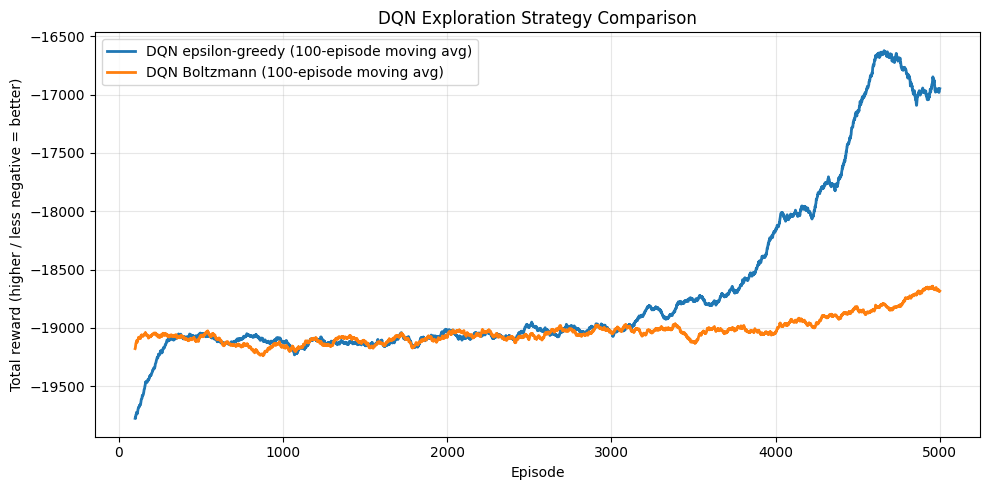

Algorithm       | Avg reward, first 500  | Avg reward, last 500  
-----------------------------------------------------------------
DQN epsilon-greedy | -19279.8               | -16826.0              
DQN Boltzmann   | -19094.1               | -18756.0              


In [27]:
# =============================================================
# STEP 5B: RUN THE DQN EXPLORATION COMPARISON
# =============================================================
#
# These are expensive runs. Use 5000 episodes for the final report.
#
# For a quick code check first, temporarily change:
#
#     DQN_EXPLORATION_EPISODES = 200
#
# Then return it to 5000 for the final experiment.
# =============================================================

DQN_EXPLORATION_EPISODES = 5000


dqn_epsilon_model, dqn_epsilon_rewards, dqn_epsilon_queues, _ = train_dqn_final(
    num_episodes=DQN_EXPLORATION_EPISODES,
    seed=42,
    exploration="epsilon_greedy"
)


dqn_boltzmann_model, dqn_boltzmann_rewards, dqn_boltzmann_queues, _ = train_dqn_final(
    num_episodes=DQN_EXPLORATION_EPISODES,
    seed=42,
    exploration="boltzmann"
)


plot_comparison(
    {
        "DQN epsilon-greedy": dqn_epsilon_rewards,
        "DQN Boltzmann": dqn_boltzmann_rewards
    },
    window=100,
    title="DQN Exploration Strategy Comparison"
)


print_comparison_summary(
    {
        "DQN epsilon-greedy": dqn_epsilon_rewards,
        "DQN Boltzmann": dqn_boltzmann_rewards
    }
)

# **Step 7 — Sensor-noise comparison completed for all learned agents**

Sensor noise changes what the agent **observes**, not the real traffic state used to calculate reward.

```text
TRUE TRAFFIC STATE
        |
        +-----------------------> reward calculation
        |
        v
  add sensor noise
        |
        v
OBSERVED TRAFFIC STATE
        |
        v
      agent
        |
        v
     action
```

Two noise levels are tested:

- `sensor_noise_range = 1`
- `sensor_noise_range = 2`

The tabular methods may be somewhat protected from small noise because several nearby exact values fall into the same Low/High bucket. DQN receives full-precision measurements, so its policy can be more sensitive to noisy observations.

In [ ]:
# =============================================================
# STEP 7A: Q-LEARNING AND SARSA SENSOR-NOISE EXPERIMENT
# =============================================================

NOISE_EPISODES = 5000


Q_clean_final, q_clean_rewards, q_clean_queues = train_tabular_final(
    algorithm="q_learning",
    exploration="epsilon_greedy",
    num_episodes=NOISE_EPISODES,
    seed=42
)


Q_q_noise1, q_noise1_rewards, q_noise1_queues = train_tabular_final(
    algorithm="q_learning",
    exploration="epsilon_greedy",
    num_episodes=NOISE_EPISODES,
    seed=42,
    use_sensor_noise=True,
    sensor_noise_range=1
)


Q_q_noise2, q_noise2_rewards, q_noise2_queues = train_tabular_final(
    algorithm="q_learning",
    exploration="epsilon_greedy",
    num_episodes=NOISE_EPISODES,
    seed=42,
    use_sensor_noise=True,
    sensor_noise_range=2
)


Q_sarsa_clean_final, sarsa_clean_rewards, sarsa_clean_queues = train_tabular_final(
    algorithm="sarsa",
    exploration="epsilon_greedy",
    num_episodes=NOISE_EPISODES,
    seed=42
)


Q_sarsa_noise1, sarsa_noise1_rewards, sarsa_noise1_queues = train_tabular_final(
    algorithm="sarsa",
    exploration="epsilon_greedy",
    num_episodes=NOISE_EPISODES,
    seed=42,
    use_sensor_noise=True,
    sensor_noise_range=1
)


Q_sarsa_noise2, sarsa_noise2_rewards, sarsa_noise2_queues = train_tabular_final(
    algorithm="sarsa",
    exploration="epsilon_greedy",
    num_episodes=NOISE_EPISODES,
    seed=42,
    use_sensor_noise=True,
    sensor_noise_range=2
)


plot_comparison(
    {
        "Q clean": q_clean_rewards,
        "Q noise ±1": q_noise1_rewards,
        "Q noise ±2": q_noise2_rewards
    },
    window=100,
    title="Q-Learning: Sensor Noise"
)


plot_comparison(
    {
        "SARSA clean": sarsa_clean_rewards,
        "SARSA noise ±1": sarsa_noise1_rewards,
        "SARSA noise ±2": sarsa_noise2_rewards
    },
    window=100,
    title="SARSA: Sensor Noise"
)

q_learning |  epsilon_greedy | episode   500/5000 | avg reward=-19472.0 | states=1980
q_learning |  epsilon_greedy | episode  1000/5000 | avg reward=-19201.7 | states=2754
q_learning |  epsilon_greedy | episode  1500/5000 | avg reward=-19048.0 | states=3262
q_learning |  epsilon_greedy | episode  2000/5000 | avg reward=-19064.9 | states=3598
q_learning |  epsilon_greedy | episode  2500/5000 | avg reward=-18999.6 | states=3797
q_learning |  epsilon_greedy | episode  3000/5000 | avg reward=-19021.1 | states=3947
q_learning |  epsilon_greedy | episode  3500/5000 | avg reward=-19042.4 | states=4027
q_learning |  epsilon_greedy | episode  4000/5000 | avg reward=-18964.6 | states=4070
q_learning |  epsilon_greedy | episode  4500/5000 | avg reward=-18976.6 | states=4079
q_learning |  epsilon_greedy | episode  5000/5000 | avg reward=-18975.9 | states=4086
q_learning |  epsilon_greedy | episode   500/5000 | avg reward=-19472.0 | states=2095
q_learning |  epsilon_greedy | episode  1000/5000 | av

DQN |  epsilon_greedy | episode   500/5000 | avg reward=-19269.0
DQN |  epsilon_greedy | episode  1000/5000 | avg reward=-18433.9
DQN |  epsilon_greedy | episode  1500/5000 | avg reward=-18343.0
DQN |  epsilon_greedy | episode  2000/5000 | avg reward=-18361.4
DQN |  epsilon_greedy | episode  2500/5000 | avg reward=-18370.7
DQN |  epsilon_greedy | episode  3000/5000 | avg reward=-18299.7
DQN |  epsilon_greedy | episode  3500/5000 | avg reward=-18285.3
DQN |  epsilon_greedy | episode  4000/5000 | avg reward=-18119.0
DQN |  epsilon_greedy | episode  4500/5000 | avg reward=-17698.4
DQN |  epsilon_greedy | episode  5000/5000 | avg reward=-17532.9
DQN |  epsilon_greedy | episode   500/5000 | avg reward=-19358.7
DQN |  epsilon_greedy | episode  1000/5000 | avg reward=-19146.3
DQN |  epsilon_greedy | episode  1500/5000 | avg reward=-19080.1
DQN |  epsilon_greedy | episode  2000/5000 | avg reward=-19068.7
DQN |  epsilon_greedy | episode  2500/5000 | avg reward=-19064.4
DQN |  epsilon_greedy | e

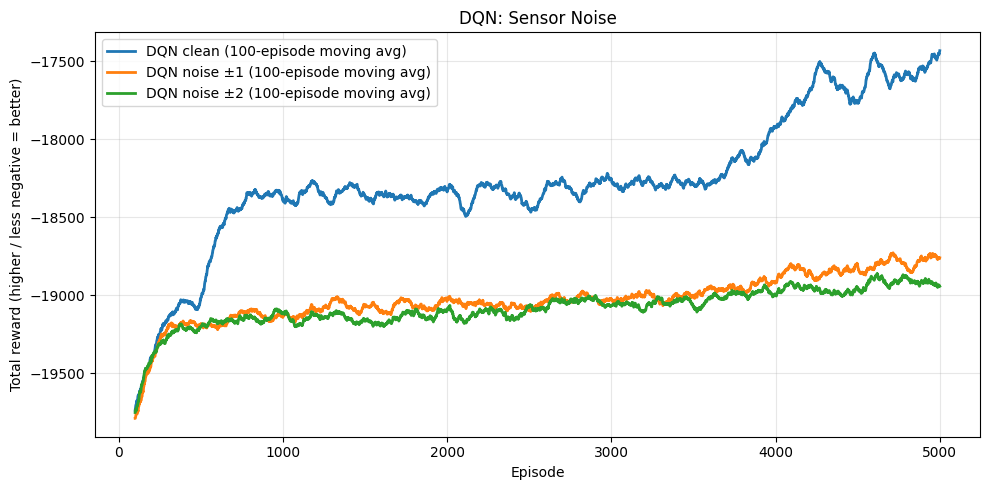

In [29]:
# =============================================================
# STEP 7B: DQN SENSOR-NOISE EXPERIMENT
# =============================================================
#
# DQN sees all 16 queue values directly rather than bucketed
# Low/High states.
#
#               exact queue value
#                       |
#       +---------------+---------------+
#       |                               |
#       v                               v
#  TABULAR METHOD                     DQN
#       |                               |
#       v                               v
#  bucket Low/High              keep exact measurement
#       |                               |
# small noise may not            small noise can change
# change the bucket              the neural-network input
#
# =============================================================

DQN_NOISE_EPISODES = 5000


dqn_clean_final, dqn_clean_rewards, dqn_clean_queues, _ = train_dqn_final(
    num_episodes=DQN_NOISE_EPISODES,
    seed=42,
    exploration="epsilon_greedy"
)


dqn_noise1_model, dqn_noise1_rewards, dqn_noise1_queues, _ = train_dqn_final(
    num_episodes=DQN_NOISE_EPISODES,
    seed=42,
    exploration="epsilon_greedy",
    use_sensor_noise=True,
    sensor_noise_range=1
)


dqn_noise2_model, dqn_noise2_rewards, dqn_noise2_queues, _ = train_dqn_final(
    num_episodes=DQN_NOISE_EPISODES,
    seed=42,
    exploration="epsilon_greedy",
    use_sensor_noise=True,
    sensor_noise_range=2
)


plot_comparison(
    {
        "DQN clean": dqn_clean_rewards,
        "DQN noise ±1": dqn_noise1_rewards,
        "DQN noise ±2": dqn_noise2_rewards
    },
    window=100,
    title="DQN: Sensor Noise"
)

# **Reward-shaping experiment — required critical analysis**

The base reward minimizes total congestion:

```text
reward = - total number of queued cars
```

Two additional shaping ideas are tested:

```text
BASE REWARD
    |
    +---- blocked-car penalty
    |         |
    |         v
    |   discourage spillback /
    |   failed movement
    |
    +---- fairness penalty
              |
              v
        discourage leaving one
        movement unserved too long
```

The important point is that reward shaping can improve one behavior while hurting another.  
For example, a fairness penalty may serve a small neglected queue even when the globally largest queue should be prioritized.

In [30]:
# =============================================================
# DETAILED POLICY EVALUATION
# =============================================================
#
# Training reward alone is NOT enough for reward shaping because
# different reward formulas are on different numerical scales.
#
# Therefore shaped policies are evaluated using common physical
# traffic metrics:
#
#   - base congestion reward
#   - average queue per step
#   - blocked cars per episode
#   - average maximum starvation time
#
# =============================================================


def evaluate_policy_detailed(
    policy_type,
    policy=None,
    num_episodes=200,
    seed_start=10000,
    max_queue_length=20,
    num_buckets=2,
    max_steps=100,
    use_sensor_noise=False,
    sensor_noise_range=1
):

    use_argmax = (
        policy_type == "baseline"
    )

    env = Traffic_Four_Way_Intersection_Environment(
        max_queue_length=max_queue_length,
        max_steps=max_steps,
        use_argmax_policy=use_argmax,
        use_sensor_noise=use_sensor_noise,
        sensor_noise_range=sensor_noise_range,

        # IMPORTANT:
        # Evaluation uses the BASE reward so every trained policy
        # is scored on the same scale.
        use_blocked_penalty=False,
        use_fairness_penalty=False
    )

    rewards = []
    queues = []
    blocked_totals = []
    max_starvation_values = []

    if policy_type == "dqn":
        device = next(
            policy.parameters()
        ).device
        policy.eval()

    for episode in range(num_episodes):

        state, _ = env.reset(
            seed=seed_start + episode
        )

        total_reward = 0.0
        total_queue = 0.0
        total_blocked = 0.0
        episode_max_starvation = 0.0

        terminated = False
        truncated = False

        while not (
            terminated
            or
            truncated
        ):

            if policy_type == "baseline":

                # Environment ignores this placeholder and
                # automatically serves the true largest queue.
                action = 0

            elif policy_type == "tabular":

                state_key = discretize_state(
                    state,
                    max_queue_length=max_queue_length,
                    num_buckets=num_buckets
                )

                q_values = policy.get(
                    state_key,
                    np.zeros(
                        env.action_space.n
                    )
                )

                action = int(
                    np.argmax(q_values)
                )

            elif policy_type == "dqn":

                normalized_state = (
                    state.astype(np.float32)
                    / max_queue_length
                )

                state_tensor = torch.tensor(
                    normalized_state,
                    dtype=torch.float32,
                    device=device
                ).unsqueeze(0)

                with torch.no_grad():

                    action = int(
                        torch.argmax(
                            policy(state_tensor),
                            dim=1
                        ).item()
                    )

            else:
                raise ValueError(
                    "policy_type must be baseline, tabular, or dqn"
                )

            (
                state,
                reward,
                terminated,
                truncated,
                info
            ) = env.step(action)

            total_reward += reward

            total_queue += (
                info["total_system_queue"]
            )

            total_blocked += (
                info["blocked_by_outgoing"]
                + info["blocked_arrivals"]
            )

            episode_max_starvation = max(
                episode_max_starvation,
                float(
                    np.max(
                        info["steps_since_served"]
                    )
                )
            )

        rewards.append(
            total_reward
        )

        queues.append(
            total_queue
        )

        blocked_totals.append(
            total_blocked
        )

        max_starvation_values.append(
            episode_max_starvation
        )

    env.close()

    return {
        "Average Reward / Episode":
            float(np.mean(rewards)),

        "Average Cumulative Queue / Episode":
            float(np.mean(queues)),

        "Average Queue / Step":
            float(np.mean(queues) / max_steps),

        "Average Blocked Cars / Episode":
            float(np.mean(blocked_totals)),

        "Average Maximum Starvation":
            float(np.mean(max_starvation_values))
    }

In [31]:
# =============================================================
# REWARD-SHAPING TRAINING AND COMPARISON
# =============================================================

REWARD_SHAPING_EPISODES = 5000


Q_reward_base, _, _ = train_tabular_final(
    algorithm="q_learning",
    num_episodes=REWARD_SHAPING_EPISODES,
    seed=42
)


Q_reward_blocked, _, _ = train_tabular_final(
    algorithm="q_learning",
    num_episodes=REWARD_SHAPING_EPISODES,
    seed=42,
    use_blocked_penalty=True,
    blocked_penalty_weight=1.0
)


Q_reward_fairness, _, _ = train_tabular_final(
    algorithm="q_learning",
    num_episodes=REWARD_SHAPING_EPISODES,
    seed=42,
    use_fairness_penalty=True,
    fairness_penalty_weight=0.1
)


Q_reward_combined, _, _ = train_tabular_final(
    algorithm="q_learning",
    num_episodes=REWARD_SHAPING_EPISODES,
    seed=42,
    use_blocked_penalty=True,
    blocked_penalty_weight=1.0,
    use_fairness_penalty=True,
    fairness_penalty_weight=0.1
)


reward_shaping_results = pd.DataFrame([
    {
        "Reward Design": "Base congestion reward",
        **evaluate_policy_detailed(
            "tabular",
            Q_reward_base
        )
    },
    {
        "Reward Design": "Blocked-car penalty",
        **evaluate_policy_detailed(
            "tabular",
            Q_reward_blocked
        )
    },
    {
        "Reward Design": "Fairness penalty",
        **evaluate_policy_detailed(
            "tabular",
            Q_reward_fairness
        )
    },
    {
        "Reward Design": "Combined shaping",
        **evaluate_policy_detailed(
            "tabular",
            Q_reward_combined
        )
    }
])


print(
    "REWARD-SHAPING BEHAVIOR COMPARISON"
)

display(
    reward_shaping_results
)

q_learning |  epsilon_greedy | episode   500/5000 | avg reward=-19471.2 | states=2019
q_learning |  epsilon_greedy | episode  1000/5000 | avg reward=-19193.6 | states=2757
q_learning |  epsilon_greedy | episode  1500/5000 | avg reward=-19103.0 | states=3254
q_learning |  epsilon_greedy | episode  2000/5000 | avg reward=-19058.2 | states=3626
q_learning |  epsilon_greedy | episode  2500/5000 | avg reward=-19028.6 | states=3814
q_learning |  epsilon_greedy | episode  3000/5000 | avg reward=-18996.3 | states=3962
q_learning |  epsilon_greedy | episode  3500/5000 | avg reward=-19036.5 | states=4033
q_learning |  epsilon_greedy | episode  4000/5000 | avg reward=-19022.7 | states=4068
q_learning |  epsilon_greedy | episode  4500/5000 | avg reward=-18950.6 | states=4087
q_learning |  epsilon_greedy | episode  5000/5000 | avg reward=-18962.6 | states=4093
q_learning |  epsilon_greedy | episode   500/5000 | avg reward=-19988.7 | states=1992
q_learning |  epsilon_greedy | episode  1000/5000 | av

,Reward Design,Average Reward / Episode,Average Cumulative Queue / Episode,Average Queue / Step,Average Blocked Cars / Episode,Average Maximum Starvation
0,Base congestion reward,-18902.120,18902.120,189.02120,573.460,95.625
1,Blocked-car penalty,-19137.170,19137.170,191.37170,726.930,99.220
2,Fairness penalty,-18952.765,18952.765,189.52765,560.440,96.045
3,Combined shaping,-18913.360,18913.360,189.13360,639.765,98.695


# **Step 8b — Canonical Final Evaluation (seed=42, reproducible)**

> **This is the canonical, reported result** (reproducible with `GLOBAL_SEED = 42`, set in Step 7). It supersedes Step 8a and is the number quoted in the paper and slides. See the reconciliation note at the end of Step 8a for why the two sections' numbers differ.

The baseline, Q-learning, SARSA, and DQN are compared using the same evaluation seeds, under clean observations and two sensor-noise levels.

```text
                 SAME TEST TRAFFIC
                         |
          +--------------+--------------+
          |              |              |
          v              v              v
      BASELINE       Q-LEARNING       SARSA       DQN
          |              |              |           |
          +--------------+--------------+-----------+
                         |
                         v
                SAME PHYSICAL METRICS
```

For noisy evaluation:

```text
TRUE STATE
   |
   +---- baseline uses the environment's true largest queue
   |
   +---- learned agents receive noisy observations
```

This makes the baseline a useful upper-information heuristic reference, while the learned policies demonstrate robustness to imperfect sensing.

In [32]:
# =============================================================
# FINAL CLEAN + NOISY FOUR-WAY COMPARISON
# =============================================================
#
# This table completes the final comparison requirement.
#
# It uses:
#
#   baseline
#   Q-learning
#   SARSA
#   DQN
#
# under:
#
#   clean observations
#   sensor noise ±1
#   sensor noise ±2
#
# =============================================================


def build_final_comparison_table(
    q_policy,
    sarsa_policy,
    dqn_policy,
    evaluation_episodes=200
):

    rows = []

    conditions = [
        ("Clean", False, 1),
        ("Noise ±1", True, 1),
        ("Noise ±2", True, 2)
    ]

    for (
        condition_name,
        use_noise,
        noise_range
    ) in conditions:

        # Baseline uses true queue values internally.
        baseline_metrics = evaluate_policy_detailed(
            "baseline",
            num_episodes=evaluation_episodes,
            use_sensor_noise=use_noise,
            sensor_noise_range=noise_range
        )

        rows.append({
            "Condition":
                condition_name,
            "Algorithm":
                "Baseline",
            **baseline_metrics
        })

        q_metrics = evaluate_policy_detailed(
            "tabular",
            q_policy,
            num_episodes=evaluation_episodes,
            use_sensor_noise=use_noise,
            sensor_noise_range=noise_range
        )

        rows.append({
            "Condition":
                condition_name,
            "Algorithm":
                "Q-Learning",
            **q_metrics
        })

        sarsa_metrics = evaluate_policy_detailed(
            "tabular",
            sarsa_policy,
            num_episodes=evaluation_episodes,
            use_sensor_noise=use_noise,
            sensor_noise_range=noise_range
        )

        rows.append({
            "Condition":
                condition_name,
            "Algorithm":
                "SARSA",
            **sarsa_metrics
        })

        dqn_metrics = evaluate_policy_detailed(
            "dqn",
            dqn_policy,
            num_episodes=evaluation_episodes,
            use_sensor_noise=use_noise,
            sensor_noise_range=noise_range
        )

        rows.append({
            "Condition":
                condition_name,
            "Algorithm":
                "DQN",
            **dqn_metrics
        })

    return pd.DataFrame(rows)


# Use the reproducible clean policies trained in Step 7.
final_clean_noisy_results = build_final_comparison_table(
    q_policy=Q_clean_final,
    sarsa_policy=Q_sarsa_clean_final,
    dqn_policy=dqn_clean_final,
    evaluation_episodes=200
)


display(
    final_clean_noisy_results
)

,Condition,Algorithm,Average Reward / Episode,Average Cumulative Queue / Episode,Average Queue / Step,Average Blocked Cars / Episode,Average Maximum Starvation
0,Clean,Baseline,-20559.205,20559.205,205.59205,502.085,88.455
1,Clean,Q-Learning,-18943.020,18943.020,189.43020,633.745,98.555
2,Clean,SARSA,-18904.640,18904.640,189.04640,563.690,94.055
3,Clean,DQN,-17411.260,17411.260,174.11260,724.470,100.000
4,Noise ±1,Baseline,-20566.070,20566.070,205.66070,503.815,87.870
5,Noise ±1,Q-Learning,-18973.035,18973.035,189.73035,639.675,98.100
6,Noise ±1,SARSA,-18879.265,18879.265,188.79265,563.125,93.010
7,Noise ±1,DQN,-17491.640,17491.640,174.91640,728.755,100.000
8,Noise ±2,Baseline,-20566.070,20566.070,205.66070,503.815,87.870
9,Noise ±2,Q-Learning,-18856.255,18856.255,188.56255,628.410,96.545


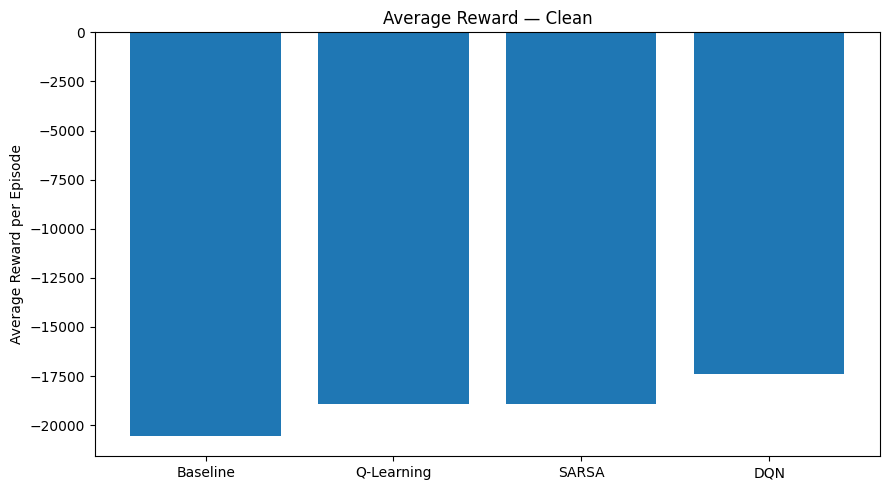

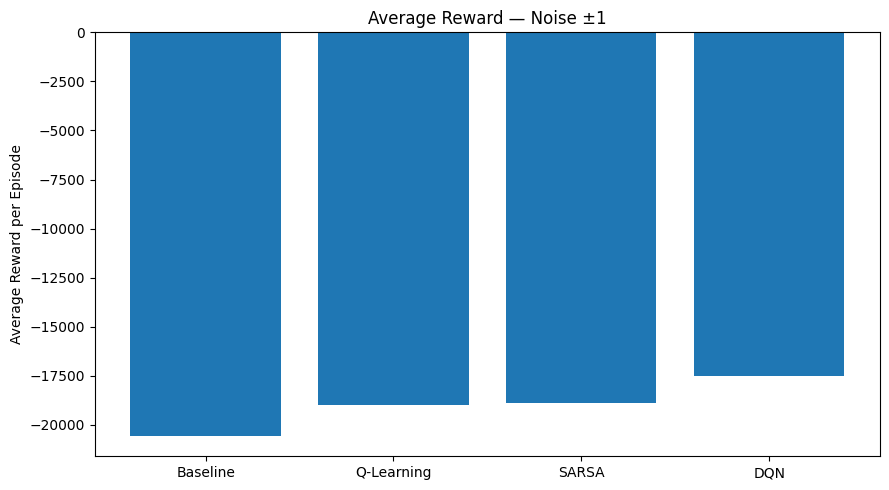

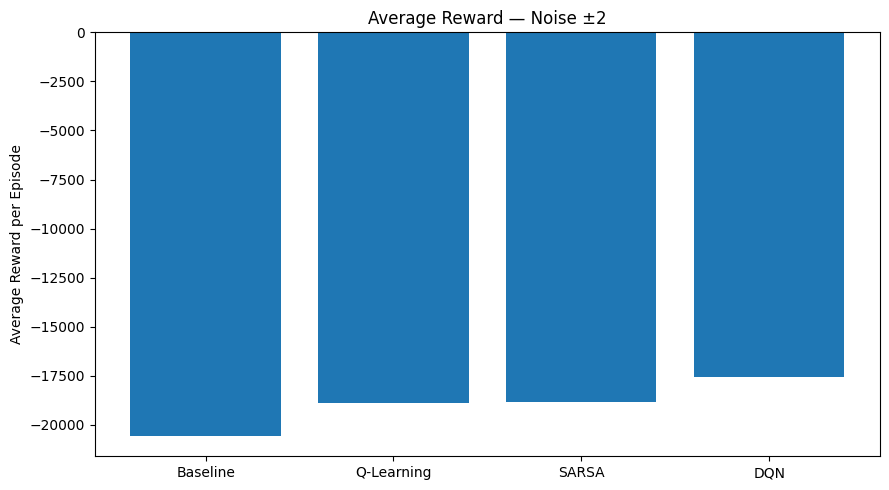

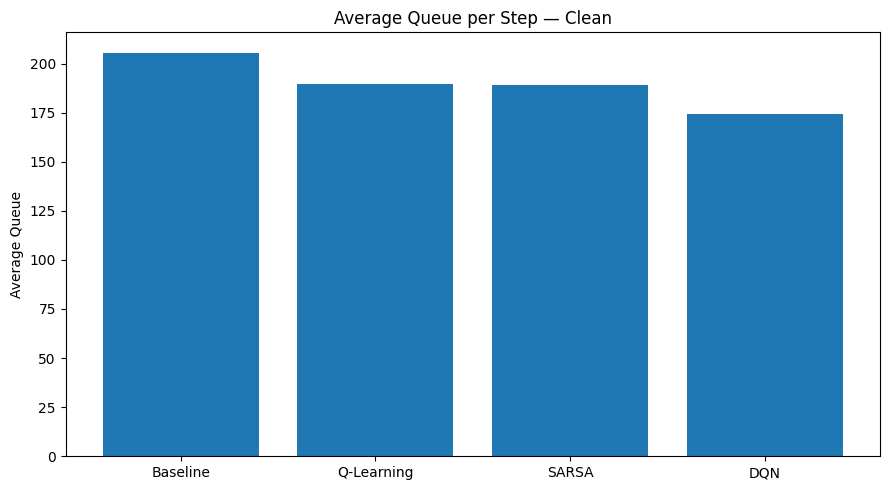

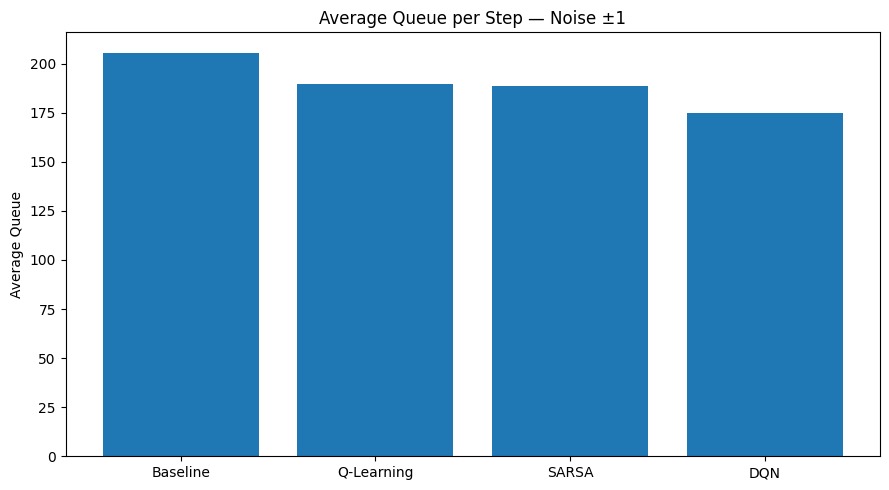

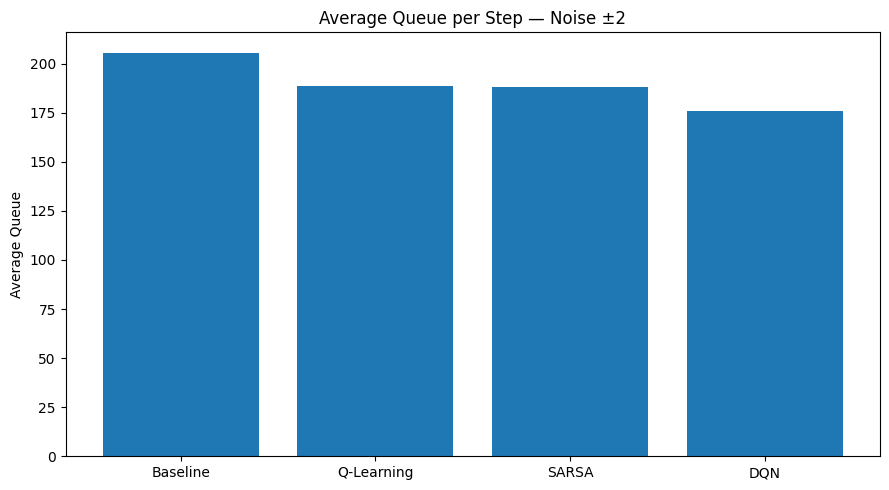

In [33]:
# =============================================================
# FINAL REPORT CHARTS: CLEAN + NOISY COMPARISON
# =============================================================

import matplotlib.pyplot as plt


for condition in [
    "Clean",
    "Noise ±1",
    "Noise ±2"
]:

    subset = final_clean_noisy_results[
        final_clean_noisy_results[
            "Condition"
        ] == condition
    ]

    plt.figure(
        figsize=(9, 5)
    )

    plt.bar(
        subset["Algorithm"],
        subset[
            "Average Reward / Episode"
        ]
    )

    plt.title(
        f"Average Reward — {condition}"
    )

    plt.ylabel(
        "Average Reward per Episode"
    )

    plt.tight_layout()

    plt.show()


for condition in [
    "Clean",
    "Noise ±1",
    "Noise ±2"
]:

    subset = final_clean_noisy_results[
        final_clean_noisy_results[
            "Condition"
        ] == condition
    ]

    plt.figure(
        figsize=(9, 5)
    )

    plt.bar(
        subset["Algorithm"],
        subset[
            "Average Queue / Step"
        ]
    )

    plt.title(
        f"Average Queue per Step — {condition}"
    )

    plt.ylabel(
        "Average Queue"
    )

    plt.tight_layout()

    plt.show()

# **Step 9 — Report-ready critical analysis**

## Q-learning vs. SARSA

The recorded 5,000-episode runs showed SARSA finishing with a better average reward than Q-learning (`-18,824.3` versus `-19,011.1` over the final 500 episodes). The earlier 15,000-episode experiment showed the same general pattern, with SARSA around `-18,820.8` and Q-learning around `-18,960.8` near the end.

A reasonable explanation is the difference between **off-policy** and **on-policy** learning.

```text
Q-LEARNING
learns toward:
"what if I take the best next action?"

SARSA
learns toward:
"what next action will my actual exploratory policy take?"
```

In a traffic system with spillback and limited outgoing capacity, a risky exploratory decision can create congestion that persists for several later steps. SARSA directly learns while accounting for this exploratory behavior, so it can prefer policies that are more conservative under continued exploration. Q-learning instead learns toward an ideal greedy continuation and may underestimate the practical cost of exploratory mistakes.

---

## Exploration strategy

The recorded tabular Q-learning experiment produced a final-500 average reward of approximately:

- epsilon-greedy: `-19,011.1`
- Boltzmann: `-18,947.4`

Boltzmann exploration was slightly better in that run. Epsilon-greedy treats every random exploratory action equally, including actions currently believed to be very poor. Boltzmann exploration assigns probabilities according to relative Q-values, so it can continue exploring while favoring actions that already appear promising.

The new DQN experiment in Step 5 repeats this comparison with function approximation.

---

## Discount factor gamma

The recorded SARSA runs gave:

- gamma = 0.5: `-19,002.6`
- gamma = 0.9: `-18,824.3`
- gamma = 0.99: `-18,881.5`

Gamma `0.9` performed best in those runs. A low gamma can make the agent too short-sighted, while a gamma extremely close to 1 can make learning targets more sensitive to distant and noisy consequences. The middle setting balanced immediate queue reduction with future congestion.

The completed notebook now repeats the gamma study for **both Q-learning and SARSA**.

---

## Learning rate alpha

The recorded SARSA runs gave:

- alpha = 0.01: `-18,980.1`
- alpha = 0.1: `-18,824.3`
- alpha = 0.5: `-19,122.5`

Alpha `0.1` performed best. The smallest value learned slowly, while the largest made Q-values react too aggressively to individual transitions. A moderate update size was more stable.

The completed notebook now repeats the alpha study for **both Q-learning and SARSA**.

---

## Sensor noise and the sim-to-real gap

The existing tabular noise experiments showed only a moderate performance decrease under small observation errors. This is consistent with the two-bucket state representation:

```text
true queue = 7
noise = +1
observed queue = 8

Both may still map to the same:
LOW or HIGH bucket
```

Therefore small measurement errors can disappear during discretization.

DQN is different because it uses the exact 16 queue measurements. A one-car sensor error changes its numerical input directly. The completed DQN sensor-noise section tests whether this makes the neural policy more sensitive.

This experiment is a concrete example of the **sim-to-real gap**: a policy trained with exact simulator observations may perform differently when real sensors contain error, delay, missed detections, or occlusion.

---

## Reward shaping

The base objective minimizes total congestion, but that objective alone does not explicitly care whether a particular movement is repeatedly ignored or whether cars are blocked by downstream capacity.

Reward shaping introduces these concerns:

- blocked-car penalty: discourages decisions that create or tolerate spillback;
- fairness penalty: discourages leaving one movement unserved for too long.

However, shaping can also create unintended behavior. An overly large fairness penalty can cause the agent to serve a nearly empty movement simply because it has waited a long time, even when another approach has severe congestion. This demonstrates why reward shaping must be evaluated using physical metrics, not only the shaped reward number.

The reward-shaping experiment therefore compares average queue, blocked cars, and starvation time under a common unshaped evaluation.

---

## Why tabular methods eventually become inadequate

With 16 queue values and each queue taking values from 0 to 20, the exact discrete state count is:

```text
21^16
```

which is far too large for a practical Q-table.

The project therefore reduces each queue to two buckets:

```text
LOW / HIGH

2^16 = 65,536 possible bucketed states
```

This makes tabular Q-learning and SARSA possible, but different exact traffic states are forced into the same bucket. Once the table has learned the best action for a bucket, further training cannot recover information that was discarded by discretization.

This can create a **discretization ceiling**.

DQN does not require these buckets:

```text
16 exact queue values
        |
        v
neural-network function approximation
        |
        v
12 estimated action values
```

The recorded 5,000-episode training results support this advantage: the DQN final-500 average reward was approximately `-18,292.2`, compared with `-18,824.3` for SARSA and `-19,011.1` for Q-learning.

---

## Safety and real-world deployment

A real adaptive traffic controller should not be deployed directly from this simulator. Important differences include pedestrian phases, emergency vehicles, yellow and all-red clearance intervals, protected turns, detector failures, communication latency, legal timing constraints, and multi-intersection coordination.

A safer deployment process would be:

```text
custom simulator
      |
      v
SUMO or another higher-fidelity traffic simulator
      |
      v
hardware-in-the-loop / shadow mode
      |
      v
restricted pilot with safety overrides
      |
      v
continuous monitoring
```

The RL controller should also be constrained by hard safety rules. Learning should decide among **safe signal phases**, rather than being allowed to violate minimum green times or activate conflicting movements.

# **Step 10 — Simple intersection visualization for the presentation demo**

The function below turns a 16-value state into a visual intersection dashboard.

```text
                  N_N
                   ↑

       incoming queues from North

W_W  ←       INTERSECTION       →  E_E

       incoming queues from South

                   ↓
                  S_S
```

This is intentionally a lightweight visualization rather than a full traffic simulator such as SUMO.

In [34]:
# =============================================================
# SIMPLE INTERSECTION STATE VISUALIZATION
# =============================================================
#
# This is a presentation/demo helper.
#
# INPUT:
#     a 16-value state
#
# OUTPUT:
#     a simple diagram showing:
#
#       - 12 incoming movement queue values
#       - 4 outgoing road queue values
#       - optional selected green movement
#
# =============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def plot_intersection_state(
    state,
    selected_movement=None,
    title="Traffic Intersection State"
):

    state = np.asarray(state)

    if state.shape[0] != 16:
        raise ValueError(
            "The current environment state must contain 16 values."
        )

    names = [
        "N_W", "N_S", "N_E",
        "S_W", "S_N", "S_E",
        "E_N", "E_S", "E_W",
        "W_N", "W_S", "W_E",
        "N_N", "S_S", "E_E", "W_W"
    ]

    values = dict(
        zip(
            names,
            state
        )
    )

    fig, ax = plt.subplots(
        figsize=(11, 8)
    )

    ax.set_xlim(
        -6,
        6
    )

    ax.set_ylim(
        -5,
        5
    )

    ax.axis(
        "off"
    )

    # Intersection center.
    center = Rectangle(
        (-1.4, -1.2),
        2.8,
        2.4,
        fill=False,
        linewidth=2
    )

    ax.add_patch(
        center
    )

    ax.text(
        0,
        0,
        "INTERSECTION",
        ha="center",
        va="center",
        fontsize=13
    )

    # ---------------------------------------------------------
    # OUTGOING ROADS
    # ---------------------------------------------------------

    ax.text(
        0,
        4.3,
        f"N_N\n{values['N_N']} cars",
        ha="center",
        va="center",
        fontsize=12
    )

    ax.text(
        0,
        -4.3,
        f"S_S\n{values['S_S']} cars",
        ha="center",
        va="center",
        fontsize=12
    )

    ax.text(
        5,
        0,
        f"E_E\n{values['E_E']} cars",
        ha="center",
        va="center",
        fontsize=12
    )

    ax.text(
        -5,
        0,
        f"W_W\n{values['W_W']} cars",
        ha="center",
        va="center",
        fontsize=12
    )

    # ---------------------------------------------------------
    # 12 INCOMING MOVEMENT QUEUES
    # ---------------------------------------------------------

    positions = {


        # North origin
        "N_W": (-2.0, 2.8),
        "N_S": (0.0, 2.8),
        "N_E": (2.0, 2.8),

        # South origin
        "S_W": (-2.0, -2.8),
        "S_N": (0.0, -2.8),
        "S_E": (2.0, -2.8),

        # East origin
        "E_N": (3.6, 1.6),
        "E_S": (3.6, 0.0),
        "E_W": (3.6, -1.6),

        # West origin
        "W_N": (-3.6, 1.6),
        "W_S": (-3.6, 0.0),
        "W_E": (-3.6, -1.6)
    }

    for movement, (
        x,
        y
    ) in positions.items():

        marker = (
            "  <-- GREEN"
            if movement
            == selected_movement
            else ""
        )

        ax.text(
            x,
            y,
            f"{movement}: "
            f"{values[movement]}"
            f"{marker}",
            ha="center",
            va="center",
            fontsize=10
        )

    # Direction arrows.
    ax.annotate(
        "",
        xy=(0, 3.8),
        xytext=(0, 1.3),
        arrowprops=dict(
            arrowstyle="->"
        )
    )

    ax.annotate(
        "",
        xy=(0, -3.8),
        xytext=(0, -1.3),
        arrowprops=dict(
            arrowstyle="->"
        )
    )

    ax.annotate(
        "",
        xy=(4.4, 0),
        xytext=(1.5, 0),
        arrowprops=dict(
            arrowstyle="->"
        )
    )

    ax.annotate(
        "",
        xy=(-4.4, 0),
        xytext=(-1.5, 0),
        arrowprops=dict(
            arrowstyle="->"
        )
    )

    ax.set_title(
        title,
        fontsize=16
    )

    plt.tight_layout()

    plt.show()


# Example:
#
# demo_env = Traffic_Four_Way_Intersection_Environment()
# demo_state, _ = demo_env.reset(seed=42)
#
# plot_intersection_state(
#     demo_state,
#     selected_movement="N_S"
# )

# **Final checklist**

- [x] Environment and MDP
- [x] 16-dimensional state and 12 actions
- [x] Two-bucket discretization for tabular methods
- [x] Q-learning
- [x] SARSA
- [x] DQN on the full non-discretized state
- [x] Epsilon-greedy exploration
- [x] Boltzmann exploration
- [x] DQN exploration-strategy comparison
- [x] Gamma study for Q-learning and SARSA
- [x] Alpha study for Q-learning and SARSA
- [x] Sensor-noise study for Q-learning, SARSA, and DQN
- [x] Reward-shaping behavior experiment
- [x] Baseline included in final comparison
- [x] Clean and noisy final comparison
- [x] Fixed random seeds for reproducibility
- [x] Report-ready critical analysis
- [x] Sim-to-real and safety discussion
- [x] Simple presentation visualization
- [x] SUMO correctly treated as optional rather than required- [x] Duplicate Step 5 / Step 8 sections relabeled (a/b) and reconciled with an explicit note explaining numeric differences, instead of two unexplained "final" results
